## Residual MLP 

## Check GPU

In [41]:
import subprocess, warnings, platform, os, psutil, gc, time
warnings.filterwarnings('ignore')
try:
    r = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total',
                  '--format=csv,noheader'], capture_output=True, text=True)
    if r.returncode == 0:
        print('GPU:', r.stdout.strip())
    else:
        print('CPU')
except FileNotFoundError:
    print('CPU')

GPU: Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [42]:
print(f'Python  : {platform.python_version()}')
print(f'CPU     : {os.cpu_count()} logical cores')
print(f'RAM     : {psutil.virtual_memory().total/1e9:.1f} GB total  |  '
      f'{psutil.virtual_memory().available/1e9:.1f} GB free')

Python  : 3.12.12
CPU     : 4 logical cores
RAM     : 33.7 GB total  |  24.9 GB free


## Install dependencies

In [43]:
%%capture
!pip install -q torch==2.3.0 --quiet
!pip install -q scikit-learn==1.5.1 numpy==1.26.4 matplotlib seaborn joblib psutil --quiet


In [44]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from sklearn.metrics import (f1_score, accuracy_score, balanced_accuracy_score,
                              confusion_matrix, classification_report,
                              roc_curve, auc,
                              precision_recall_curve, average_precision_score,
                              roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

print(f'torch          : {torch.__version__}')
print(f'numpy          : {np.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')


torch          : 2.3.0+cu121
numpy          : 1.26.4
CUDA available : True


In [45]:
random_seed   = 42
artefacts_dir = '/kaggle/input/notebooks/hossamhamdyfakry/2-ids-preprocessing/artefacts'
plots_dir     = '/kaggle/working/plots_mlp'
models_dir    = '/kaggle/working/models_mlp'
os.makedirs(plots_dir,  exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

torch.manual_seed(random_seed)
np.random.seed(random_seed)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device : {device}')


Device : cuda


## Load Artefacts

In [46]:
le                    = joblib.load(f'{artefacts_dir}/label_encoder.pkl')
class_weight_dict     = joblib.load(f'{artefacts_dir}/class_weights.pkl')
class_weight_att_dict = joblib.load(f'{artefacts_dir}/class_weights_att.pkl')

print('Label encoder classes:')
for code, name in enumerate(le.classes_):
    print(f'  {code} : {name}')

Label encoder classes:
  0 : Analysis
  1 : Backdoor
  2 : Benign
  3 : Bot
  4 : Brute Force
  5 : DDoS
  6 : DoS
  7 : Exploits
  8 : Fuzzers
  9 : Generic
  10 : Infilteration
  11 : Reconnaissance
  12 : Shellcode
  13 : Theft
  14 : Worms
  15 : injection
  16 : mitm
  17 : password
  18 : ransomware
  19 : scanning
  20 : xss


## Load Data

In [47]:
# full_dataset — Model 1 (binary) + Model 2 (full multiclass)
X_train       = np.load(f'{artefacts_dir}/X_train.npy').astype(np.float32)
X_val         = np.load(f'{artefacts_dir}/X_val.npy').astype(np.float32)
X_test        = np.load(f'{artefacts_dir}/X_test.npy').astype(np.float32)
y_train_bin   = np.load(f'{artefacts_dir}/y_train_bin.npy').astype(np.int64)
y_val_bin     = np.load(f'{artefacts_dir}/y_val_bin.npy').astype(np.int64)
y_test_bin    = np.load(f'{artefacts_dir}/y_test_bin.npy').astype(np.int64)
y_train_multi = np.load(f'{artefacts_dir}/y_train_multi.npy').astype(np.int64)
y_val_multi   = np.load(f'{artefacts_dir}/y_val_multi.npy').astype(np.int64)
y_test_multi  = np.load(f'{artefacts_dir}/y_test_multi.npy').astype(np.int64)


## Training Set Subsampling
# For the limitation in our computing resoucres
We subsampled the training set from 13.7M down to 5M rows by capping Benign, DDoS, and DoS at 1.2M each, scanning, Reconnaissance, and xss at 400K, while keeping all rare attack classes at 100%. Val and test sets are left untouched at their original 4.56M rows each.

In [48]:

SUBSAMPLE_CAPS = {
     2 : 1_200_000,   # Benign
     5 : 1_200_000,   # DDoS
     6 : 1_200_000,   # DoS
    11 :   400_000,   # Reconnaissance
    19 :   400_000,   # scanning
    20 :   400_000,   # xss

}



In [49]:
rng = np.random.default_rng(42)
keep_idx = []
for cls_code in np.unique(y_train_multi):
    idx = np.where(y_train_multi == cls_code)[0]
    cap = SUBSAMPLE_CAPS.get(int(cls_code), len(idx))   
    if len(idx) > cap:
        idx = rng.choice(idx, size=cap, replace=False)
    keep_idx.append(idx)

keep_idx = np.concatenate(keep_idx)
keep_idx.sort()   

X_train       = X_train[keep_idx]
y_train_bin   = y_train_bin[keep_idx]
y_train_multi = y_train_multi[keep_idx]

In [50]:
print(f'Train  (subsampled) : {X_train.shape}  dtype={X_train.dtype}')
print(f'Val                 : {X_val.shape}')
print(f'Test                : {X_test.shape}')
print()
print('Train class distribution after subsampling:')
unique, counts = np.unique(y_train_multi, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  class {u:2d} : {c:>10,}')
print(f'  TOTAL   : {len(y_train_multi):>10,}')

Train  (subsampled) : (5226255, 42)  dtype=float32
Val                 : (4564510, 42)
Test                : (4564510, 42)

Train class distribution after subsampling:
  class  0 :        227
  class  1 :      3,496
  class  2 :  1,200,000
  class  3 :     11,759
  class  4 :     24,497
  class  5 :  1,200,000
  class  6 :  1,200,000
  class  7 :      5,951
  class  8 :      4,151
  class  9 :      1,933
  class 10 :     22,939
  class 11 :    400,000
  class 12 :        229
  class 13 :        422
  class 14 :         61
  class 15 :    133,775
  class 16 :      1,486
  class 17 :    214,708
  class 18 :        621
  class 19 :    400,000
  class 20 :    400,000
  TOTAL   :  5,226,255


## Evaluation Function

In [51]:
def predict_in_chunks(model, X, chunk_size=131072):
    results = []
    for start in range(0, len(X), chunk_size):
        chunk = X[start : start + chunk_size]
        preds = model.predict(chunk)
        results.append(preds.flatten().astype(int))
    return np.concatenate(results)


In [52]:
def predict_proba_in_chunks(model, X, chunk_size=131072):
    results = []
    for start in range(0, len(X), chunk_size):
        chunk = X[start : start + chunk_size]
        proba = model.predict_proba(chunk)
        results.append(proba)
    return np.vstack(results)

In [53]:
def evaluate(model, X, y, label='', class_names=None):
    preds = predict_in_chunks(model, X)          
    if hasattr(preds, 'flatten'):
        preds = preds.flatten()
    preds = preds.astype(int)
    acc   = accuracy_score(y, preds)
    mf1   = f1_score(y, preds, average='macro')
    wf1   = f1_score(y, preds, average='weighted')
    print(f"\n{'='*50}")
    print(f'{label}')
    print(f'Accuracy         : {acc:.4f}')
    print(f'Macro-F1         : {mf1:.4f}')
    print(f'Weighted-F1      : {wf1:.4f}')
    print(f"{'='*50}")
    print(classification_report(y, preds,
                                 target_names=class_names,
                                 zero_division=0))
    return preds

## Weights for multiclass models

In [54]:
def make_sample_weights(y, weight_dict):
    return np.array([weight_dict[c] for c in y], dtype=np.float32)
# smoothing out the weights
log_smoothed_multi_dict = {
    cls: max(1.0, 1.0 + np.log(weight))
    for cls, weight in class_weight_dict.items()
}

log_smoothed_att_dict = {
    cls: max(1.0, 1.0 + np.log(weight))
    for cls, weight in class_weight_att_dict.items()
}

## Residual MLP Model Definition

In [55]:
class _ResBlock(nn.Module):
    """Two-layer residual block with BatchNorm + GELU."""
    def __init__(self, in_dim, hidden_dim, dropout):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim,     hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        # projection shortcut if dims differ
        self.shortcut = (nn.Linear(in_dim, hidden_dim, bias=False)
                         if in_dim != hidden_dim else nn.Identity())

    def forward(self, x):
        return self.block(x) + self.shortcut(x)

In [56]:
class _ResMLPNet(nn.Module):
    def __init__(self, n_features, hidden_dim, n_blocks, dropout, n_classes):
        super().__init__()
        self.bn_in = nn.BatchNorm1d(n_features)
        layers = []
        in_dim = n_features
        for _ in range(n_blocks):
            layers.append(_ResBlock(in_dim, hidden_dim, dropout))
            in_dim = hidden_dim
        self.blocks = nn.Sequential(*layers)
        self.head   = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.bn_in(x)
        x = self.blocks(x)
        return self.head(x)

In [ ]:
class ResidualMLPClassifier:
    def __init__(self, hidden_dim=512, n_blocks=4, dropout=0.15,
                 lr=3e-4, weight_decay=1e-4,
                 device_name='auto', seed=42, verbose=1):
        self.hidden_dim   = hidden_dim
        self.n_blocks     = n_blocks
        self.dropout      = dropout
        self.lr           = lr
        self.weight_decay = weight_decay
        self.device_name  = device_name
        self.seed         = seed
        self.verbose      = verbose
        self.history      = {}
        self.model        = None
        self._X_sample    = None

    def _device(self):
        if self.device_name == 'auto':
            return 'cuda' if torch.cuda.is_available() else 'cpu'
        return self.device_name

    # fit 
    def fit(self, X_train, y_train, eval_set=None, eval_metric='accuracy',
            weights=None, max_epochs=8, patience=3,
            batch_size=8192, num_workers=2, drop_last=False, **kwargs):

        torch.manual_seed(self.seed);  np.random.seed(self.seed)
        dev        = self._device();   self._dev = dev
        n_features = X_train.shape[1]
        n_classes  = len(np.unique(y_train));  self.n_classes_ = n_classes

        self.model = _ResMLPNet(n_features, self.hidden_dim,
                                self.n_blocks, self.dropout,
                                n_classes).to(dev)

        optimizer = torch.optim.AdamW(self.model.parameters(),
                                      lr=self.lr, weight_decay=self.weight_decay)

        # Cosine annealing with 3-epoch linear warmup
        warmup_epochs = 3
        def lr_lambda(ep):
            if ep < warmup_epochs:
                return (ep + 1) / warmup_epochs
            prog = (ep - warmup_epochs) / max(1, max_epochs - warmup_epochs)
            return 0.5 * (1.0 + math.cos(math.pi * prog))
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

        loss_fn = nn.CrossEntropyLoss(reduction='none')
        scaler  = torch.cuda.amp.GradScaler(enabled=(dev == 'cuda'))

        from torch.utils.data import DataLoader, TensorDataset
        X_tr  = torch.tensor(X_train, dtype=torch.float32)
        y_tr  = torch.tensor(y_train, dtype=torch.long)
        use_w = weights is not None
        w_tr  = (torch.tensor(weights, dtype=torch.float32)
                 if use_w else torch.ones(len(y_tr)))
        dataset = TensorDataset(X_tr, y_tr, w_tr)
        loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                             num_workers=num_workers, drop_last=drop_last,
                             pin_memory=(dev == 'cuda'))

        X_val_t = y_val_np = None
        if eval_set:
            X_val_np, y_val_np = eval_set[0]
            X_val_t = torch.tensor(X_val_np, dtype=torch.float32).to(dev)

        metrics = eval_metric if isinstance(eval_metric, list) else [eval_metric]
        hist    = {'loss': []}
        for m in metrics:
            hist[f'val_0_{m}'] = []
        self.history = hist

        best_val, best_epoch, best_state, no_improve = -np.inf, 0, None, 0

        # Store small sample for gradient-based feature importance
        si = np.random.choice(len(X_train), min(2000, len(X_train)), replace=False)
        self._X_sample = X_train[si].copy()

        for epoch in range(max_epochs):
            t0 = time.time()
            self.model.train()
            ep_loss, n_b = 0.0, 0
            for xb, yb, wb in loader:
                xb, yb, wb = xb.to(dev), yb.to(dev), wb.to(dev)
                with torch.cuda.amp.autocast(enabled=(dev == 'cuda')):
                    losses = loss_fn(self.model(xb), yb)
                    loss   = (losses * wb).mean() if use_w else losses.mean()
                optimizer.zero_grad()
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                ep_loss += loss.item();  n_b += 1
            scheduler.step()
            avg_loss = ep_loss / max(n_b, 1)
            hist['loss'].append(avg_loss)

            if X_val_t is not None:
                self.model.eval()
                all_logits = []
                with torch.no_grad(), torch.cuda.amp.autocast(enabled=(dev=='cuda')):
                    for s in range(0, len(X_val_t), 16384):
                        all_logits.append(self.model(X_val_t[s:s+16384]))
                vl     = torch.cat(all_logits, 0)
                vp     = vl.argmax(1).cpu().numpy()
                vproba = torch.softmax(vl, 1).cpu().numpy()

                for m in metrics:
                    if   m == 'accuracy':
                        sc = accuracy_score(y_val_np, vp)
                    elif m == 'balanced_accuracy':
                        sc = balanced_accuracy_score(y_val_np, vp)
                    elif m == 'auc':
                        sc = (roc_auc_score(y_val_np, vproba[:, 1])
                              if n_classes == 2
                              else roc_auc_score(y_val_np, vproba,
                                                 multi_class='ovr'))
                    hist[f'val_0_{m}'].append(sc)

                primary = hist[f'val_0_{metrics[0]}'][-1]
                if primary > best_val:
                    best_val, best_epoch, no_improve = primary, epoch, 0
                    best_state = {k: v.cpu().clone()
                                  for k, v in self.model.state_dict().items()}
                else:
                    no_improve += 1

                elapsed = time.time() - t0
                if self.verbose:
                    ms = ' | '.join(f'val_{m}={hist[f"val_0_{m}"][-1]:.4f}'
                                    for m in metrics)
                    print(f'Epoch {epoch+1:3d} | loss={avg_loss:.4f} | {ms}'
                          f' | {elapsed:.0f}s')

                if no_improve >= patience:
                    if self.verbose:
                        print(f'Early stopping at epoch {epoch+1},'
                              f' best epoch={best_epoch+1} val={best_val:.4f}')
                    break
            else:
                if self.verbose:
                    print(f'Epoch {epoch+1:3d} | loss={avg_loss:.4f}')

        if best_state is not None:
            self.model.load_state_dict(
                {k: v.to(dev) for k, v in best_state.items()})
        return self

    #  inference helpers
    def _forward_chunks(self, X, chunk=16384):
        self.model.eval()
        out = []
        with torch.no_grad(), torch.cuda.amp.autocast(
                enabled=(self._dev == 'cuda')):
            for s in range(0, len(X), chunk):
                xb = torch.tensor(X[s:s+chunk],
                                   dtype=torch.float32).to(self._dev)
                out.append(self.model(xb))
        return torch.cat(out, 0)

    def predict(self, X):
        return self._forward_chunks(X).argmax(1).cpu().numpy()

    def predict_proba(self, X):
        return torch.softmax(self._forward_chunks(X), 1).cpu().numpy()

    # persist
    def save_model(self, path):
        torch.save({
            'state': {k: v.cpu() for k, v in self.model.state_dict().items()},
            'cfg'  : {
                'n_features' : self.model.bn_in.num_features,
                'n_classes'  : self.n_classes_,
                'hidden_dim' : self.hidden_dim,
                'n_blocks'   : self.n_blocks,
                'dropout'    : self.dropout,
            }
        }, path + '.pt')

    def load_model(self, path):
        ck  = torch.load(path, map_location=self._dev)
        cfg = ck['cfg']
        self.n_classes_ = cfg['n_classes']
        self.hidden_dim = cfg['hidden_dim']
        self.n_blocks   = cfg['n_blocks']
        self.dropout    = cfg['dropout']
        self.model = _ResMLPNet(cfg['n_features'], self.hidden_dim,
                                self.n_blocks,   self.dropout,
                                self.n_classes_).to(self._dev)
        self.model.load_state_dict(
            {k: v.to(self._dev) for k, v in ck['state'].items()})
        self.model.eval()

    #  feature importance 
    @property
    def feature_importances_(self):
        """Mean |dLoss/dInput| over a stored training sample."""
        self.model.eval()
        X_t = torch.tensor(self._X_sample, dtype=torch.float32,
                            device=self._dev, requires_grad=True)
        logits = self.model(X_t)
        logits.sum().backward()
        imp = X_t.grad.abs().mean(0).detach().cpu().numpy()
        return imp / (imp.sum() + 1e-9)

 
    def explain(self, X):
        self.model.eval()
        results = []
        for s in range(0, len(X), 4096):
            xb = torch.tensor(X[s:s+4096], dtype=torch.float32,
                               device=self._dev, requires_grad=True)
            logits = self.model(xb)
            logits.sum().backward()
            results.append(xb.grad.abs().detach().cpu().numpy())
        return np.vstack(results), None


## Model Hyperparameters

In [58]:
RESMLP_PARAMS = {
    'hidden_dim'   : 512,
    'n_blocks'     : 4,
    'dropout'      : 0.15,
    'lr'           : 3e-4,
    'weight_decay' : 1e-4,
    'device_name'  : device,
    'seed'         : random_seed,
    'verbose'      : 1,
}

FIT_PARAMS = {
    'max_epochs'  : 20,
    'patience'    : 5,
    'batch_size'  : 8192,
    'num_workers' : 2,
    'drop_last'   : False,
}


## Model 1 — Binary Classifier

In [59]:
res_bin = ResidualMLPClassifier(**RESMLP_PARAMS)

res_bin.fit(
    X_train, y_train_bin,
    eval_set    = [(X_val, y_val_bin)],
    eval_metric = ['auc'],
    weights     = None,
    **FIT_PARAMS
)

res_bin.save_model(f'{models_dir}/resmlp_binary')


Epoch   1 | loss=0.0814 | val_auc=0.9981 | 53s
Epoch   2 | loss=0.0574 | val_auc=0.9985 | 52s
Epoch   3 | loss=0.0541 | val_auc=0.9985 | 52s
Epoch   4 | loss=0.0523 | val_auc=0.9986 | 52s
Epoch   5 | loss=0.0514 | val_auc=0.9986 | 51s
Epoch   6 | loss=0.0506 | val_auc=0.9987 | 52s
Epoch   7 | loss=0.0501 | val_auc=0.9987 | 55s
Epoch   8 | loss=0.0496 | val_auc=0.9987 | 53s
Epoch   9 | loss=0.0492 | val_auc=0.9987 | 52s
Epoch  10 | loss=0.0488 | val_auc=0.9987 | 52s
Epoch  11 | loss=0.0484 | val_auc=0.9987 | 52s
Epoch  12 | loss=0.0480 | val_auc=0.9988 | 52s
Epoch  13 | loss=0.0477 | val_auc=0.9988 | 51s
Epoch  14 | loss=0.0473 | val_auc=0.9988 | 52s
Epoch  15 | loss=0.0470 | val_auc=0.9988 | 51s
Epoch  16 | loss=0.0466 | val_auc=0.9988 | 52s
Epoch  17 | loss=0.0464 | val_auc=0.9988 | 50s
Epoch  18 | loss=0.0462 | val_auc=0.9988 | 50s
Epoch  19 | loss=0.0461 | val_auc=0.9988 | 53s
Epoch  20 | loss=0.0460 | val_auc=0.9988 | 49s


In [60]:
# Free training data before prediction
del X_train, y_train_bin
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Test model_1 performance on the test set

In [61]:
preds_bin = evaluate(res_bin, X_test, y_test_bin,
                      label='Model 1 — Binary — Test Set',
                      class_names=['Benign', 'Attack'])



Model 1 — Binary — Test Set
Accuracy         : 0.9813
Macro-F1         : 0.9786
Weighted-F1      : 0.9812
              precision    recall  f1-score   support

      Benign       0.99      0.95      0.97   1493266
      Attack       0.98      1.00      0.99   3071244

    accuracy                           0.98   4564510
   macro avg       0.98      0.97      0.98   4564510
weighted avg       0.98      0.98      0.98   4564510



## Learning Curve

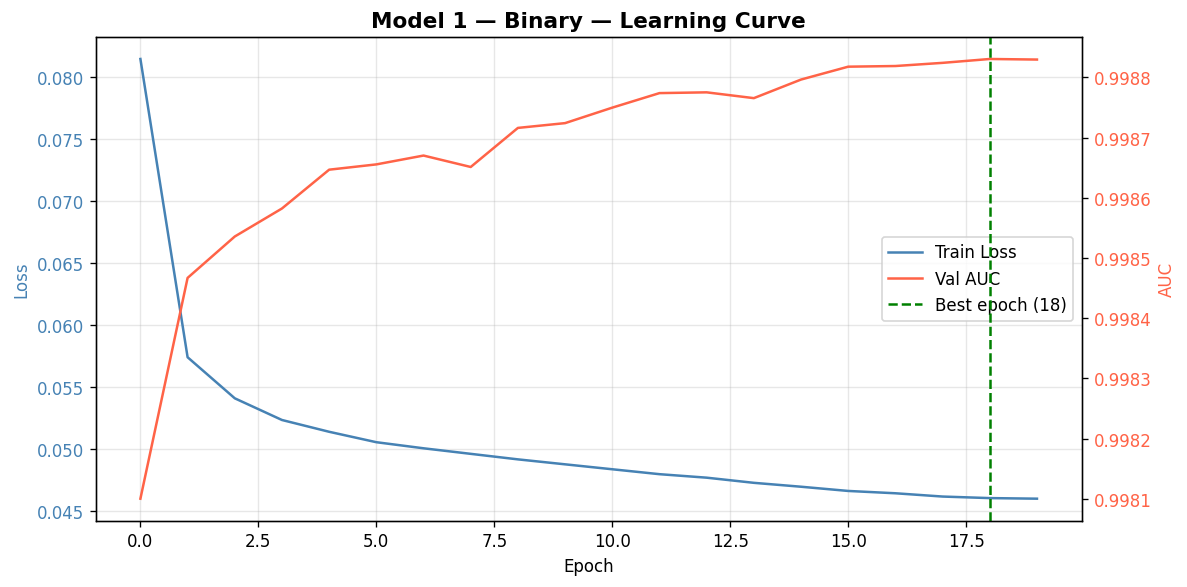

In [62]:
train_loss = res_bin.history['loss']
val_auc    = res_bin.history['val_0_auc']
best_epoch = np.argmax(val_auc)

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

ax1.plot(train_loss, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(val_auc, label='Val AUC', color='tomato')
ax2.axvline(best_epoch, color='green', linestyle='--',
            label=f'Best epoch ({best_epoch})')
ax2.set_ylabel('AUC', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Model 1 — Binary — Learning Curve', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## Confusion Matrix

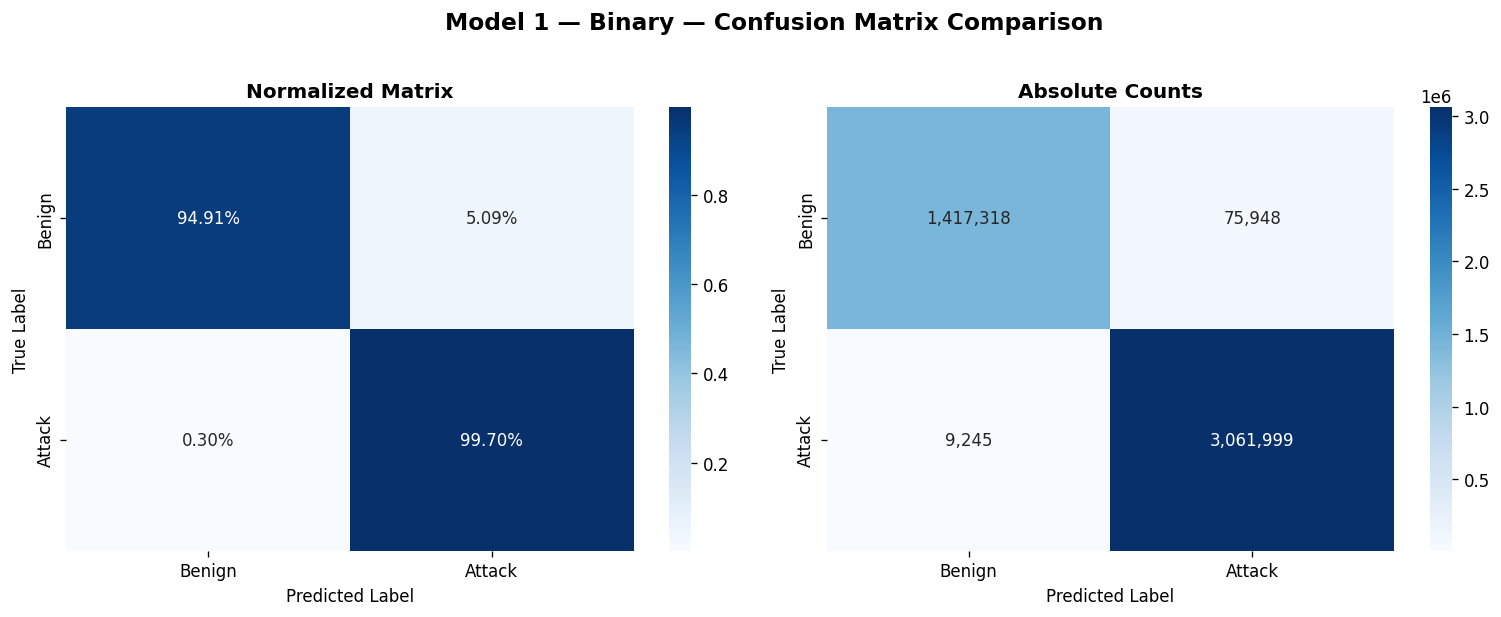

In [63]:
cm_norm = confusion_matrix(y_test_bin, preds_bin, normalize='true')
cm_raw  = confusion_matrix(y_test_bin, preds_bin)
fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=120)
labels = ['Benign', 'Attack']


sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Normalized Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')


sns.heatmap(cm_raw, annot=True, fmt=',d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Absolute Counts', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

fig.suptitle('Model 1 — Binary — Confusion Matrix Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_confusion_matrix_side_by_side.png', dpi=120, bbox_inches='tight')
plt.show()

## ROC Curve

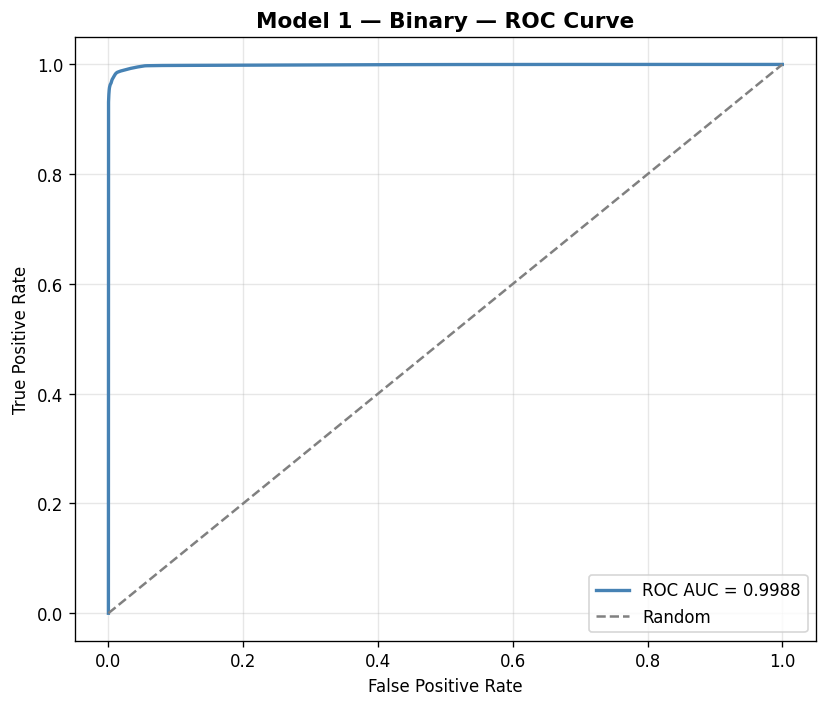

In [64]:
proba_bin   = predict_proba_in_chunks(res_bin, X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test_bin, proba_bin)
roc_auc     = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random')
ax.set_title('Model 1 — Binary — ROC Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_roc.png', dpi=120, bbox_inches='tight')
plt.show()


##  Precision-Recall Curve

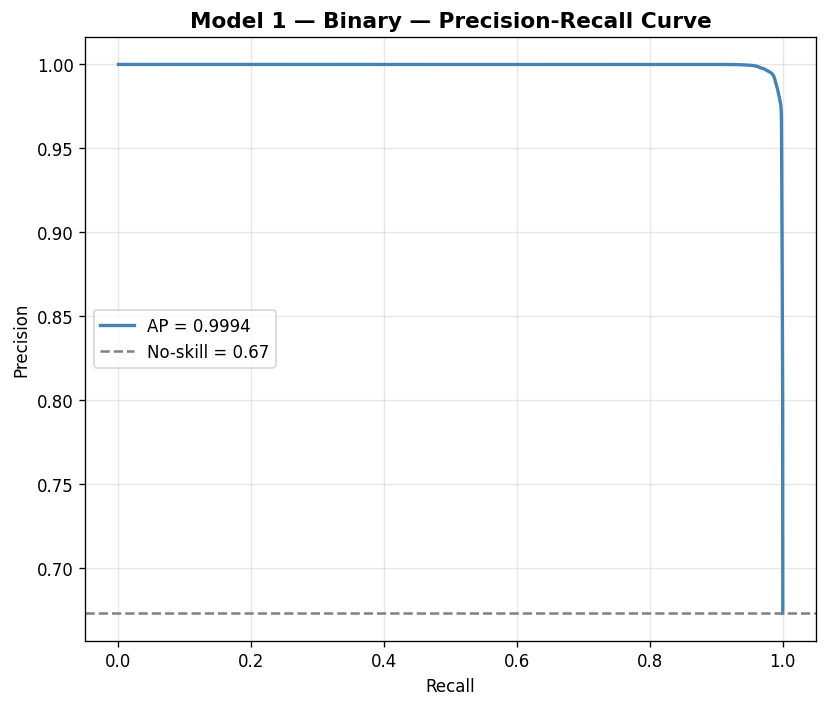

In [65]:
precision, recall, _ = precision_recall_curve(y_test_bin, proba_bin)
ap       = average_precision_score(y_test_bin, proba_bin)
no_skill = y_test_bin.mean()

fig, ax = plt.subplots(figsize=(7, 6), dpi=120)
ax.plot(recall, precision, color='steelblue', lw=2, label=f'AP = {ap:.4f}')
ax.axhline(no_skill, color='gray', linestyle='--', label=f'No-skill = {no_skill:.2f}')
ax.set_title('Model 1 — Binary — Precision-Recall Curve', fontsize=13, fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_pr_curve.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance (Gradient-based, Top 20)

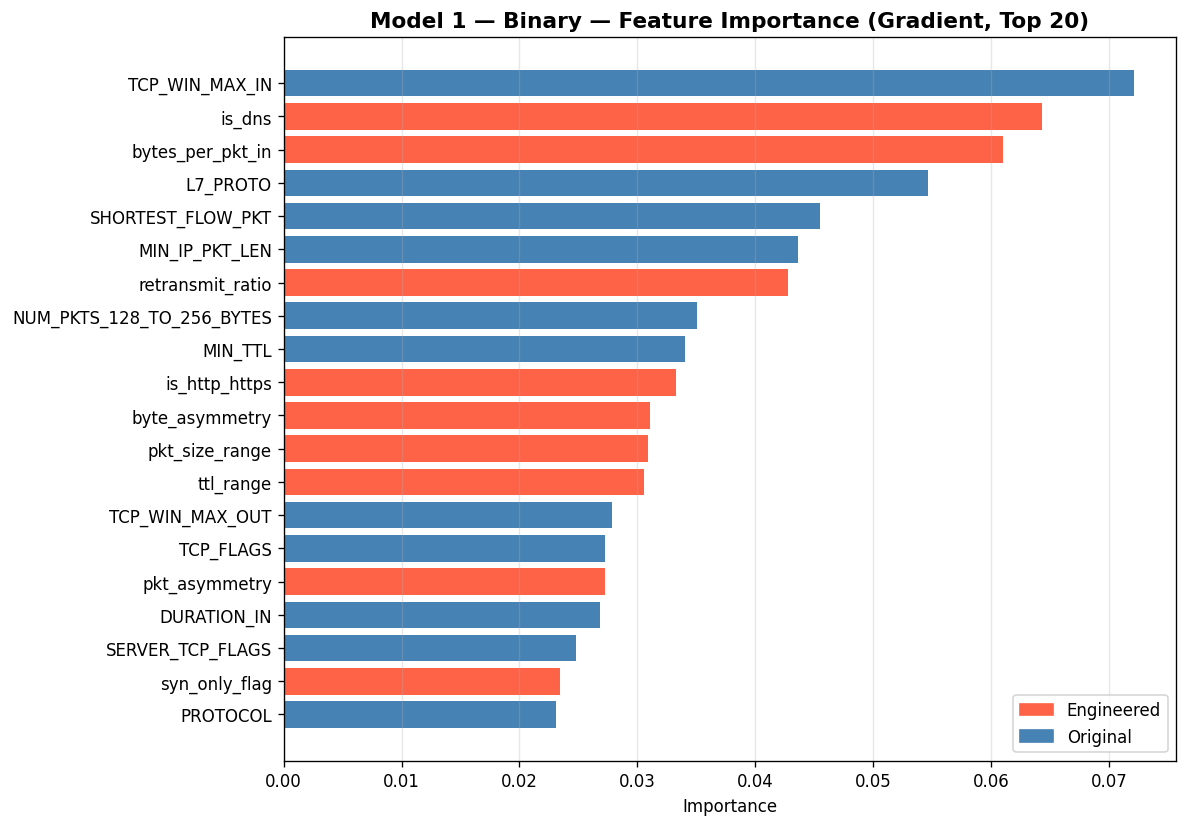

In [66]:
mi_cols    = joblib.load(f'{artefacts_dir}/mi_selected_cols.pkl')
engineered = {
    'bytes_per_pkt_in', 'bytes_per_pkt_out', 'upload_ratio',
    'byte_asymmetry', 'pkt_asymmetry', 'is_http_https',
    'is_ssh_telnet', 'is_dns', 'ttl_range', 'syn_only_flag',
    'pkt_size_range', 'retransmit_ratio', 'retransmit_pkt_ratio'
}

importance = res_bin.feature_importances_
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 1 — Binary — Feature Importance (Gradient, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m1_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


In [67]:
# Save preds to disk and free RAM
np.save(f'{models_dir}/preds_bin.npy', preds_bin)
del preds_bin
del res_bin
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


7038

## Model 2
## Full Multiclass

In [68]:
# Reload training data for Model 2, reapply same subsample mask
X_train       = np.load(f'{artefacts_dir}/X_train.npy').astype(np.float32)[keep_idx]
y_train_multi = np.load(f'{artefacts_dir}/y_train_multi.npy').astype(np.int64)[keep_idx]
print(f'Reloaded X_train for Model 2 : {X_train.shape}')


Reloaded X_train for Model 2 : (5226255, 42)


In [69]:
res_multi = ResidualMLPClassifier(**RESMLP_PARAMS)

res_multi.fit(
    X_train, y_train_multi,
    eval_set    = [(X_val, y_val_multi)],
    eval_metric = ['accuracy', 'balanced_accuracy'],
    weights     = make_sample_weights(y_train_multi, log_smoothed_multi_dict),
    **FIT_PARAMS
)
res_multi.save_model(f'{models_dir}/resmlp_multiclass')


Epoch   1 | loss=0.3876 | val_accuracy=0.9566 | val_balanced_accuracy=0.7736 | 51s
Epoch   2 | loss=0.2616 | val_accuracy=0.9610 | val_balanced_accuracy=0.7788 | 49s
Epoch   3 | loss=0.2435 | val_accuracy=0.9620 | val_balanced_accuracy=0.7992 | 50s
Epoch   4 | loss=0.2330 | val_accuracy=0.9628 | val_balanced_accuracy=0.8293 | 52s
Epoch   5 | loss=0.2266 | val_accuracy=0.9637 | val_balanced_accuracy=0.8146 | 54s
Epoch   6 | loss=0.2220 | val_accuracy=0.9632 | val_balanced_accuracy=0.7975 | 56s
Epoch   7 | loss=0.2187 | val_accuracy=0.9646 | val_balanced_accuracy=0.8110 | 55s
Epoch   8 | loss=0.2159 | val_accuracy=0.9643 | val_balanced_accuracy=0.8143 | 54s
Epoch   9 | loss=0.2137 | val_accuracy=0.9647 | val_balanced_accuracy=0.8406 | 54s
Epoch  10 | loss=0.2112 | val_accuracy=0.9655 | val_balanced_accuracy=0.7889 | 54s
Epoch  11 | loss=0.2092 | val_accuracy=0.9654 | val_balanced_accuracy=0.7922 | 53s
Epoch  12 | loss=0.2074 | val_accuracy=0.9657 | val_balanced_accuracy=0.8205 | 55s
Epoc

In [70]:
# Free training data before prediction
del X_train, y_train_multi
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Test model_2 performance on the test set

In [71]:
preds_multi = evaluate(res_multi, X_test, y_test_multi,
                        label='Model 2 — Full Multiclass — Test Set',
                        class_names=le.classes_)



Model 2 — Full Multiclass — Test Set
Accuracy         : 0.9659
Macro-F1         : 0.7629
Weighted-F1      : 0.9669
                precision    recall  f1-score   support

      Analysis       0.14      0.09      0.11        75
      Backdoor       0.79      0.98      0.87      1165
        Benign       0.99      0.95      0.97   1493266
           Bot       1.00      1.00      1.00      3920
   Brute Force       0.99      0.98      0.99      8165
          DDoS       0.99      0.99      0.99   1310954
           DoS       0.99      0.98      0.98   1088123
      Exploits       0.71      0.90      0.80      1984
       Fuzzers       0.75      0.92      0.83      1384
       Generic       0.74      0.84      0.78       645
 Infilteration       0.32      0.10      0.16      7646
Reconnaissance       0.68      0.93      0.79    166365
     Shellcode       0.59      0.97      0.74        76
         Theft       0.37      0.98      0.54       141
         Worms       0.46      0.81      0.

## Learning Curve

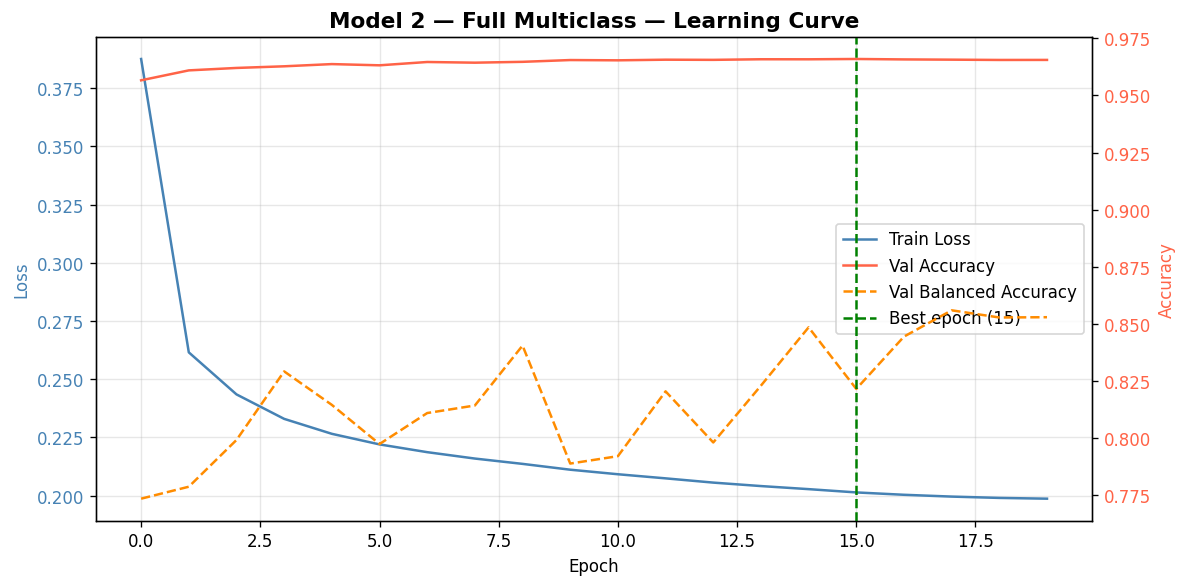

In [72]:
train_loss = res_multi.history['loss']
val_acc    = res_multi.history['val_0_accuracy']
val_bal    = res_multi.history['val_0_balanced_accuracy']
best_epoch = np.argmax(val_acc)

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

ax1.plot(train_loss, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(val_acc, label='Val Accuracy',          color='tomato')
ax2.plot(val_bal, label='Val Balanced Accuracy', color='darkorange', linestyle='--')
ax2.axvline(best_epoch, color='green', linestyle='--',
            label=f'Best epoch ({best_epoch})')
ax2.set_ylabel('Accuracy', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Model 2 — Full Multiclass — Learning Curve', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## Confusion Matrix

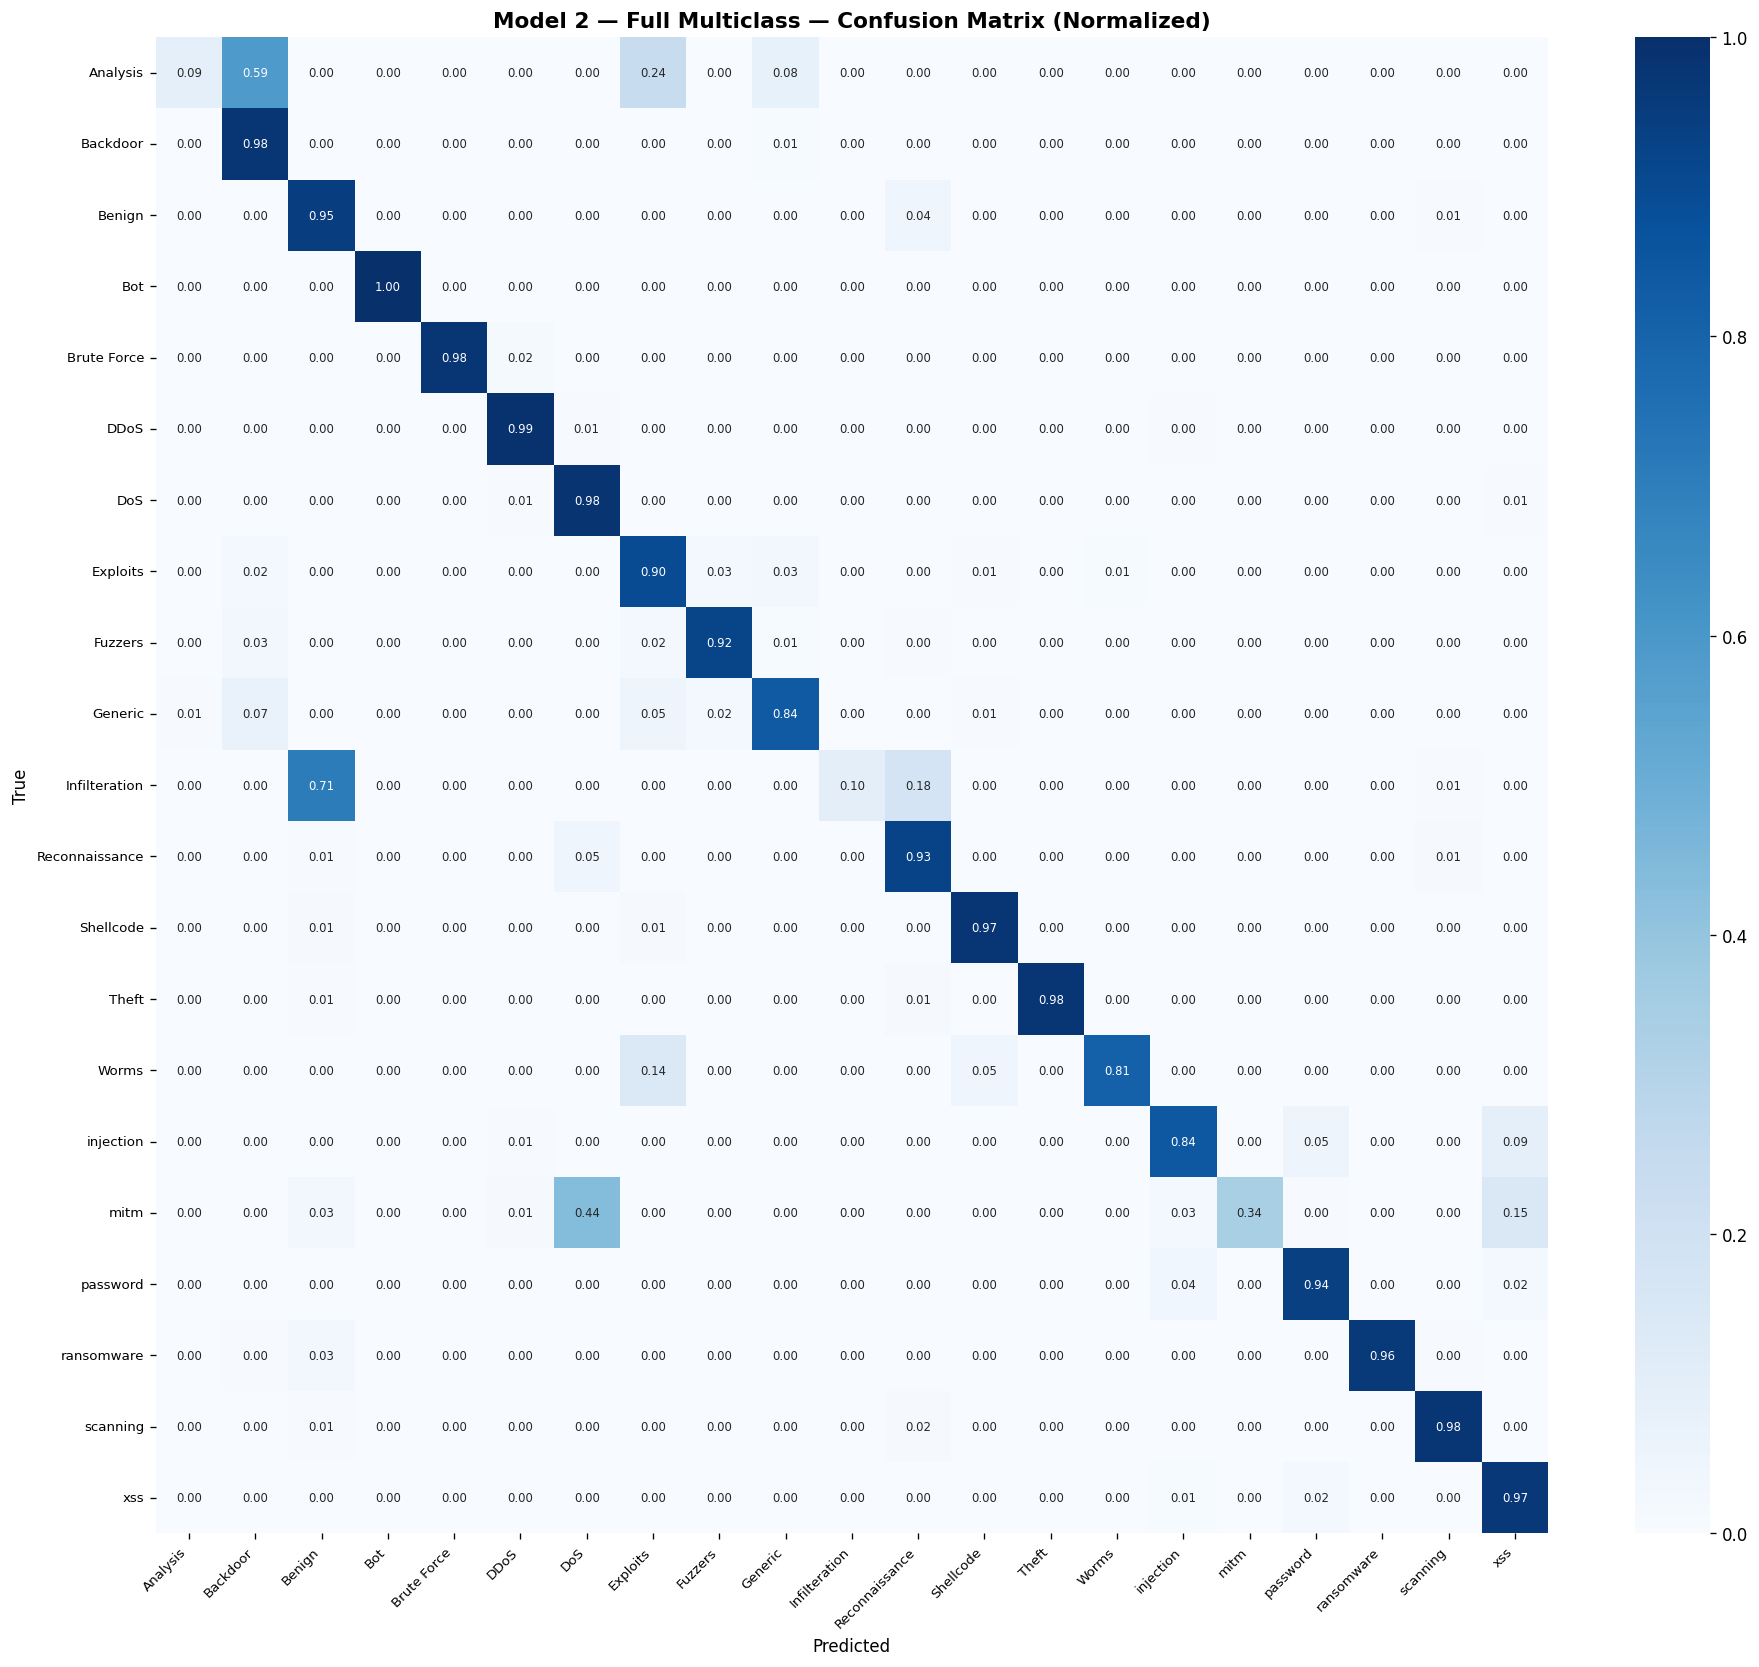

In [73]:

cm = confusion_matrix(y_test_multi, preds_multi, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Model 2 — Full Multiclass — Confusion Matrix (Normalized)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class F1 bar chart

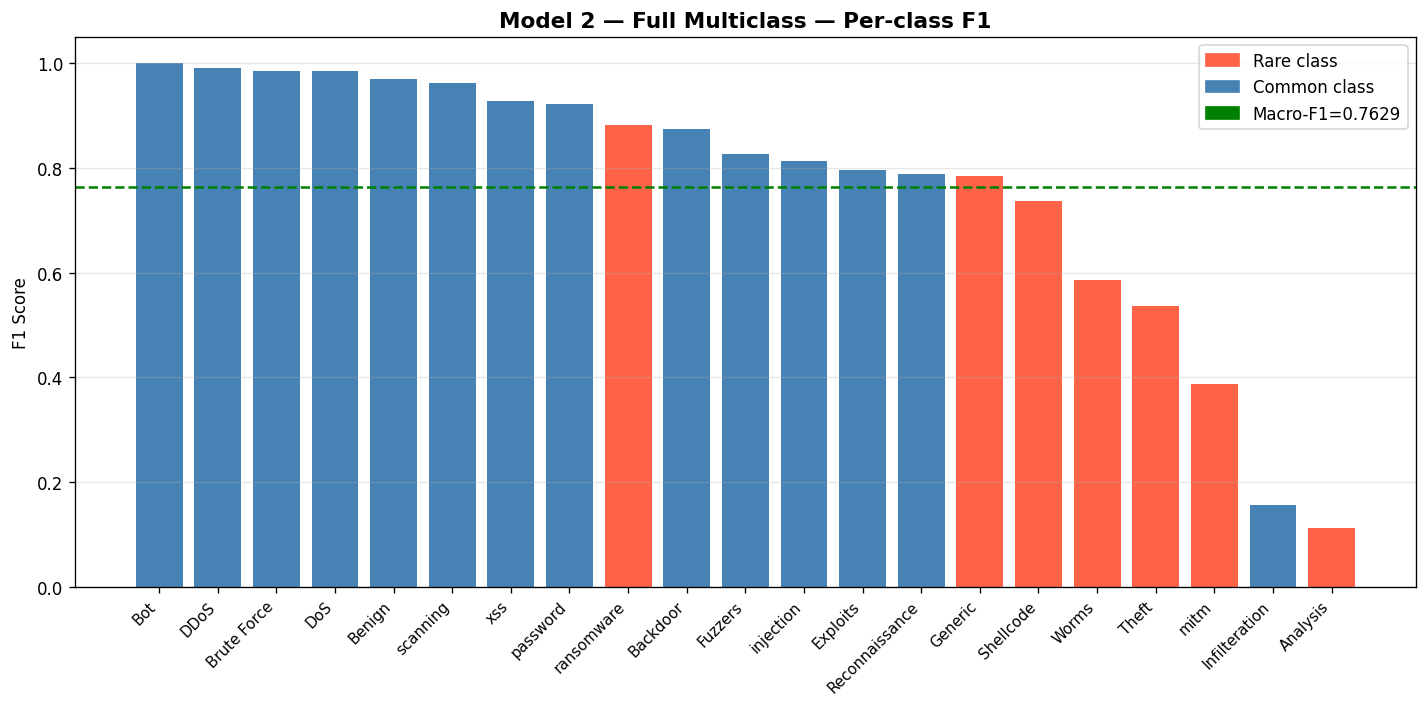

In [74]:
report   = classification_report(y_test_multi, preds_multi,
                                  target_names=le.classes_,
                                  output_dict=True, zero_division=0)
f1_vals  = {cls: report[cls]['f1-score'] for cls in le.classes_}
f1_df    = pd.DataFrame(list(f1_vals.items()), columns=['class', 'f1'])
f1_df    = f1_df.sort_values('f1', ascending=False)
macro_f1 = report['macro avg']['f1-score']

rare   = {'Worms','Shellcode','Analysis','Theft','ransomware','mitm','Generic'}
colors = ['tomato' if c in rare else 'steelblue' for c in f1_df['class']]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(f1_df['class'], f1_df['f1'], color=colors)
ax.axhline(macro_f1, color='green', linestyle='--',
           label=f'Macro-F1 = {macro_f1:.4f}')
ax.set_title('Model 2 — Full Multiclass — Per-class F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
patches = [mpatches.Patch(color='tomato',    label='Rare class'),
           mpatches.Patch(color='steelblue', label='Common class'),
           mpatches.Patch(color='green',     label=f'Macro-F1={macro_f1:.4f}')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class Precision_Recall heatmap

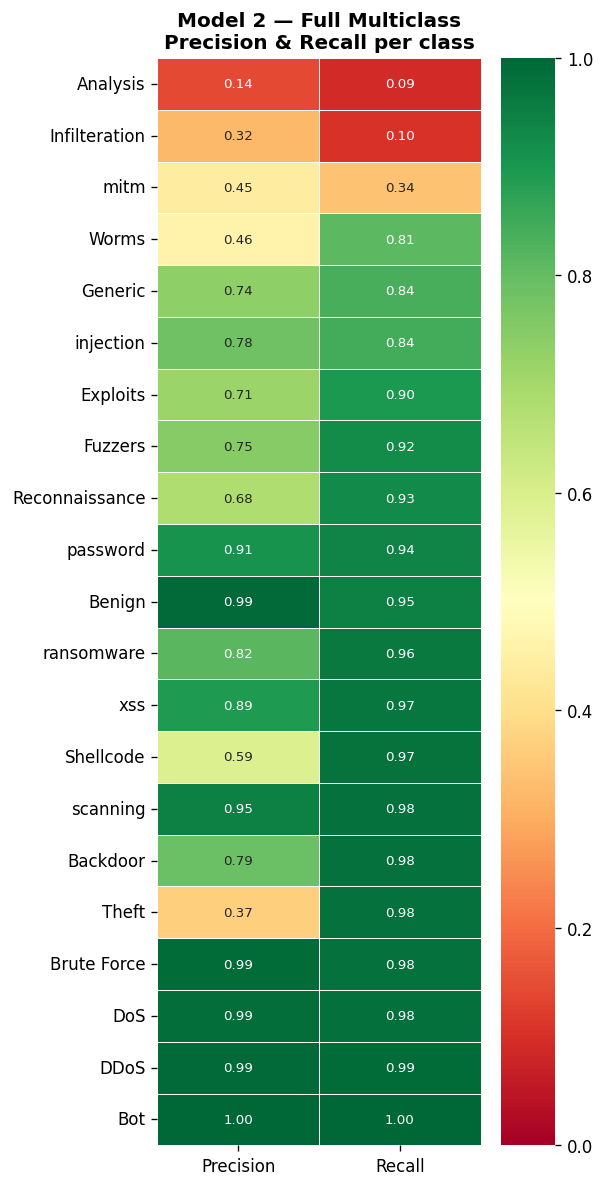

In [75]:
prec_vals = {cls: report[cls]['precision'] for cls in le.classes_}
rec_vals  = {cls: report[cls]['recall']    for cls in le.classes_}
pr_df     = pd.DataFrame({'Precision': prec_vals, 'Recall': rec_vals})
pr_df     = pr_df.sort_values('Recall', ascending=True)

fig, ax = plt.subplots(figsize=(5, 10), dpi=120)
sns.heatmap(pr_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Model 2 — Full Multiclass\nPrecision & Recall per class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_precision_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance (Gradient-based, Top 20)

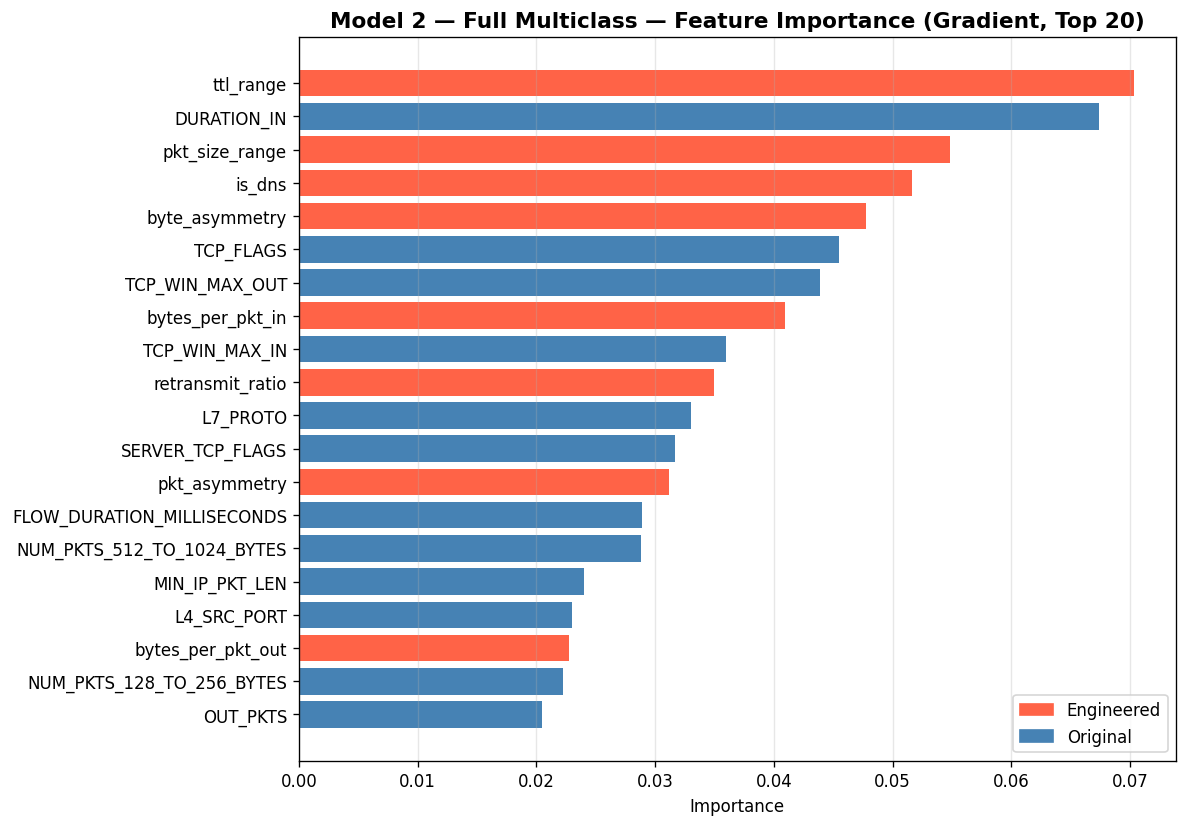

In [76]:
importance = res_multi.feature_importances_
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 2 — Full Multiclass — Feature Importance (Gradient, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m2_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


In [77]:
# Save preds to disk and free RAM
np.save(f'{models_dir}/preds_multi.npy', preds_multi)
del preds_multi
del res_multi
if torch.cuda.is_available():
    torch.cuda.empty_cache()
del X_val
del y_val_bin, y_test_bin
del y_val_multi, y_test_multi
gc.collect()


58173

## Model 3
## Attack-Only Multiclass

In [78]:
# Load attack-only arrays 
X_train_att       = np.load(f'{artefacts_dir}/X_train_att.npy').astype(np.float32)
X_val_att         = np.load(f'{artefacts_dir}/X_val_att.npy').astype(np.float32)
X_test_att        = np.load(f'{artefacts_dir}/X_test_att.npy').astype(np.float32)
y_train_att_multi = np.load(f'{artefacts_dir}/y_train_att_multi.npy').astype(np.int64)
y_val_att_multi   = np.load(f'{artefacts_dir}/y_val_att_multi.npy').astype(np.int64)
y_test_att_multi  = np.load(f'{artefacts_dir}/y_test_att_multi.npy').astype(np.int64)

print(f'Train att : {X_train_att.shape}  dtype={X_train_att.dtype}')
print(f'Val att   : {X_val_att.shape}')
print(f'Test att  : {X_test_att.shape}')


Train att : (9213731, 42)  dtype=float32
Val att   : (3071244, 42)
Test att  : (3071244, 42)


In [79]:
ATT_CAPS = {
     5 : 1_200_000,   # DDoS
     6 : 1_200_000,   # DoS
    11 :   400_000,   # Reconnaissance
    17 :   200_000,   # password  
    19 :   400_000,   # scanning
    20 :   400_000,   # xss
    
}



In [80]:
rng_att = np.random.default_rng(42)
att_keep_idx = []
for cls_code in np.unique(y_train_att_multi):
    idx = np.where(y_train_att_multi == cls_code)[0]
    cap = ATT_CAPS.get(int(cls_code), len(idx))
    if len(idx) > cap:
        idx = rng_att.choice(idx, size=cap, replace=False)
    att_keep_idx.append(idx)

att_keep_idx = np.concatenate(att_keep_idx)
att_keep_idx.sort()

X_train_att       = X_train_att[att_keep_idx]
y_train_att_multi = y_train_att_multi[att_keep_idx]

In [81]:
print(f'Train att (subsampled) : {X_train_att.shape}')
print(f'Val att                : {X_val_att.shape}')
print(f'Test att               : {X_test_att.shape}')
print()
print('Train att class distribution after subsampling:')
unique_att, counts_att = np.unique(y_train_att_multi, return_counts=True)
for u, c in zip(unique_att, counts_att):
    print(f'  class {u:2d} : {c:>10,}')
print(f'  TOTAL   : {len(y_train_att_multi):>10,}')


Train att (subsampled) : (4011547, 42)
Val att                : (3071244, 42)
Test att               : (3071244, 42)

Train att class distribution after subsampling:
  class  0 :        227
  class  1 :      3,496
  class  3 :     11,759
  class  4 :     24,497
  class  5 :  1,200,000
  class  6 :  1,200,000
  class  7 :      5,951
  class  8 :      4,151
  class  9 :      1,933
  class 10 :     22,939
  class 11 :    400,000
  class 12 :        229
  class 13 :        422
  class 14 :         61
  class 15 :    133,775
  class 16 :      1,486
  class 17 :    200,000
  class 18 :        621
  class 19 :    400,000
  class 20 :    400,000
  TOTAL   :  4,011,547


In [82]:
from sklearn.preprocessing import LabelEncoder as LE
le_att = LE()
y_train_att_remap = le_att.fit_transform(y_train_att_multi)
y_val_att_remap   = le_att.transform(y_val_att_multi)
y_test_att_remap  = le_att.transform(y_test_att_multi)

attack_classes = [c for c in le.classes_ if c != 'Benign']
n_classes_att  = len(np.unique(y_train_att_remap))

# Remap weight dict keys from original le codes
log_smoothed_att_dict = {
    int(le_att.transform([orig_code])[0]): weight
    for orig_code, weight in log_smoothed_att_dict.items()
}

print(f'Attack classes : {n_classes_att}')

Attack classes : 20


In [83]:
res_att = ResidualMLPClassifier(**RESMLP_PARAMS)

res_att.fit(
    X_train_att, y_train_att_remap,
    eval_set    = [(X_val_att, y_val_att_remap)],
    eval_metric = ['accuracy', 'balanced_accuracy'],
    weights     = make_sample_weights(y_train_att_remap, log_smoothed_att_dict),
    **FIT_PARAMS
)

res_att.save_model(f'{models_dir}/resmlp_att_multiclass')


Epoch   1 | loss=0.3202 | val_accuracy=0.9719 | val_balanced_accuracy=0.8148 | 39s
Epoch   2 | loss=0.2006 | val_accuracy=0.9742 | val_balanced_accuracy=0.8073 | 40s
Epoch   3 | loss=0.1805 | val_accuracy=0.9748 | val_balanced_accuracy=0.8366 | 41s
Epoch   4 | loss=0.1699 | val_accuracy=0.9764 | val_balanced_accuracy=0.8053 | 39s
Epoch   5 | loss=0.1640 | val_accuracy=0.9767 | val_balanced_accuracy=0.8216 | 39s
Epoch   6 | loss=0.1598 | val_accuracy=0.9772 | val_balanced_accuracy=0.8607 | 39s
Epoch   7 | loss=0.1565 | val_accuracy=0.9775 | val_balanced_accuracy=0.8490 | 39s
Epoch   8 | loss=0.1538 | val_accuracy=0.9776 | val_balanced_accuracy=0.8455 | 39s
Epoch   9 | loss=0.1516 | val_accuracy=0.9782 | val_balanced_accuracy=0.8513 | 39s
Epoch  10 | loss=0.1497 | val_accuracy=0.9785 | val_balanced_accuracy=0.8306 | 41s
Epoch  11 | loss=0.1478 | val_accuracy=0.9786 | val_balanced_accuracy=0.8475 | 38s
Epoch  12 | loss=0.1462 | val_accuracy=0.9782 | val_balanced_accuracy=0.8190 | 40s
Epoc

In [84]:
# Free training data before prediction
del X_train_att, y_train_att_remap
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## Test model_3 performance on the test set

In [85]:
preds_att = evaluate(res_att, X_test_att, y_test_att_remap,
                      label='Model 3 — Attack-Only Multiclass — Test Set',
                      class_names=attack_classes)



Model 3 — Attack-Only Multiclass — Test Set
Accuracy         : 0.9791
Macro-F1         : 0.8247
Weighted-F1      : 0.9792
                precision    recall  f1-score   support

      Analysis       0.14      0.61      0.23        75
      Backdoor       0.97      0.95      0.96      1165
           Bot       1.00      1.00      1.00      3920
   Brute Force       1.00      0.98      0.99      8165
          DDoS       0.99      0.99      0.99   1310954
           DoS       0.98      0.99      0.98   1088123
      Exploits       0.81      0.92      0.86      1984
       Fuzzers       0.92      0.93      0.92      1384
       Generic       0.81      0.82      0.81       645
 Infilteration       0.96      0.80      0.88      7646
Reconnaissance       0.96      0.93      0.95    166365
     Shellcode       0.76      0.93      0.84        76
         Theft       0.40      0.99      0.57       141
         Worms       0.64      0.33      0.44        21
     injection       0.79      0.85 

## Learning Curve

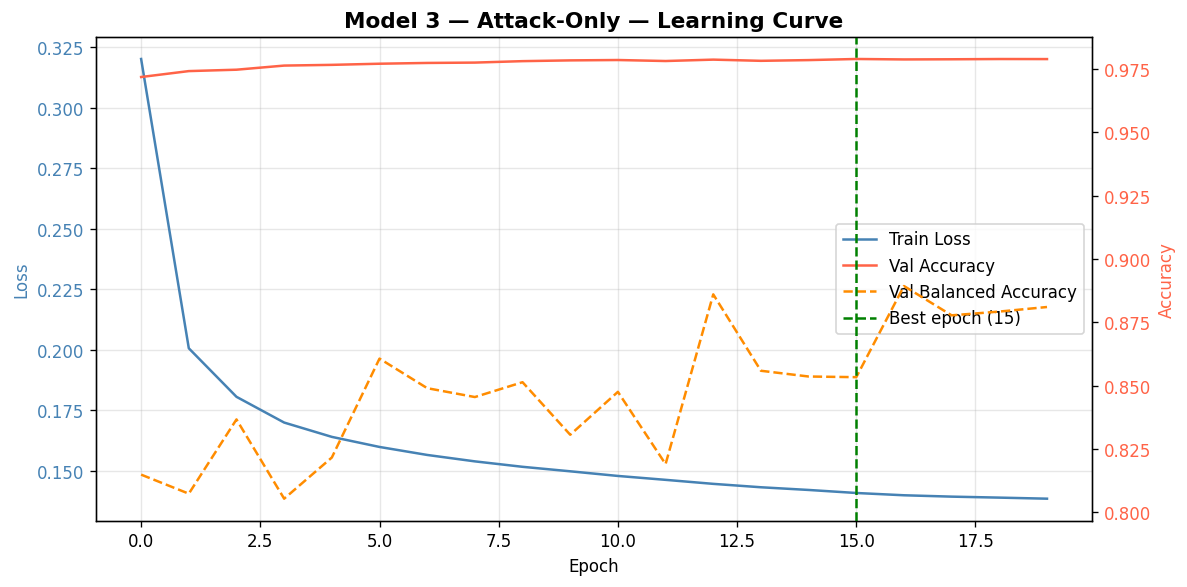

In [86]:
train_loss = res_att.history['loss']
val_acc    = res_att.history['val_0_accuracy']
val_bal    = res_att.history['val_0_balanced_accuracy']
best_epoch = np.argmax(val_acc)

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=120)

ax1.plot(train_loss, label='Train Loss', color='steelblue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(val_acc, label='Val Accuracy',          color='tomato')
ax2.plot(val_bal, label='Val Balanced Accuracy', color='darkorange', linestyle='--')
ax2.axvline(best_epoch, color='green', linestyle='--',
            label=f'Best epoch ({best_epoch})')
ax2.set_ylabel('Accuracy', color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

ax1.set_title('Model 3 — Attack-Only — Learning Curve', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## Confusion Matrix

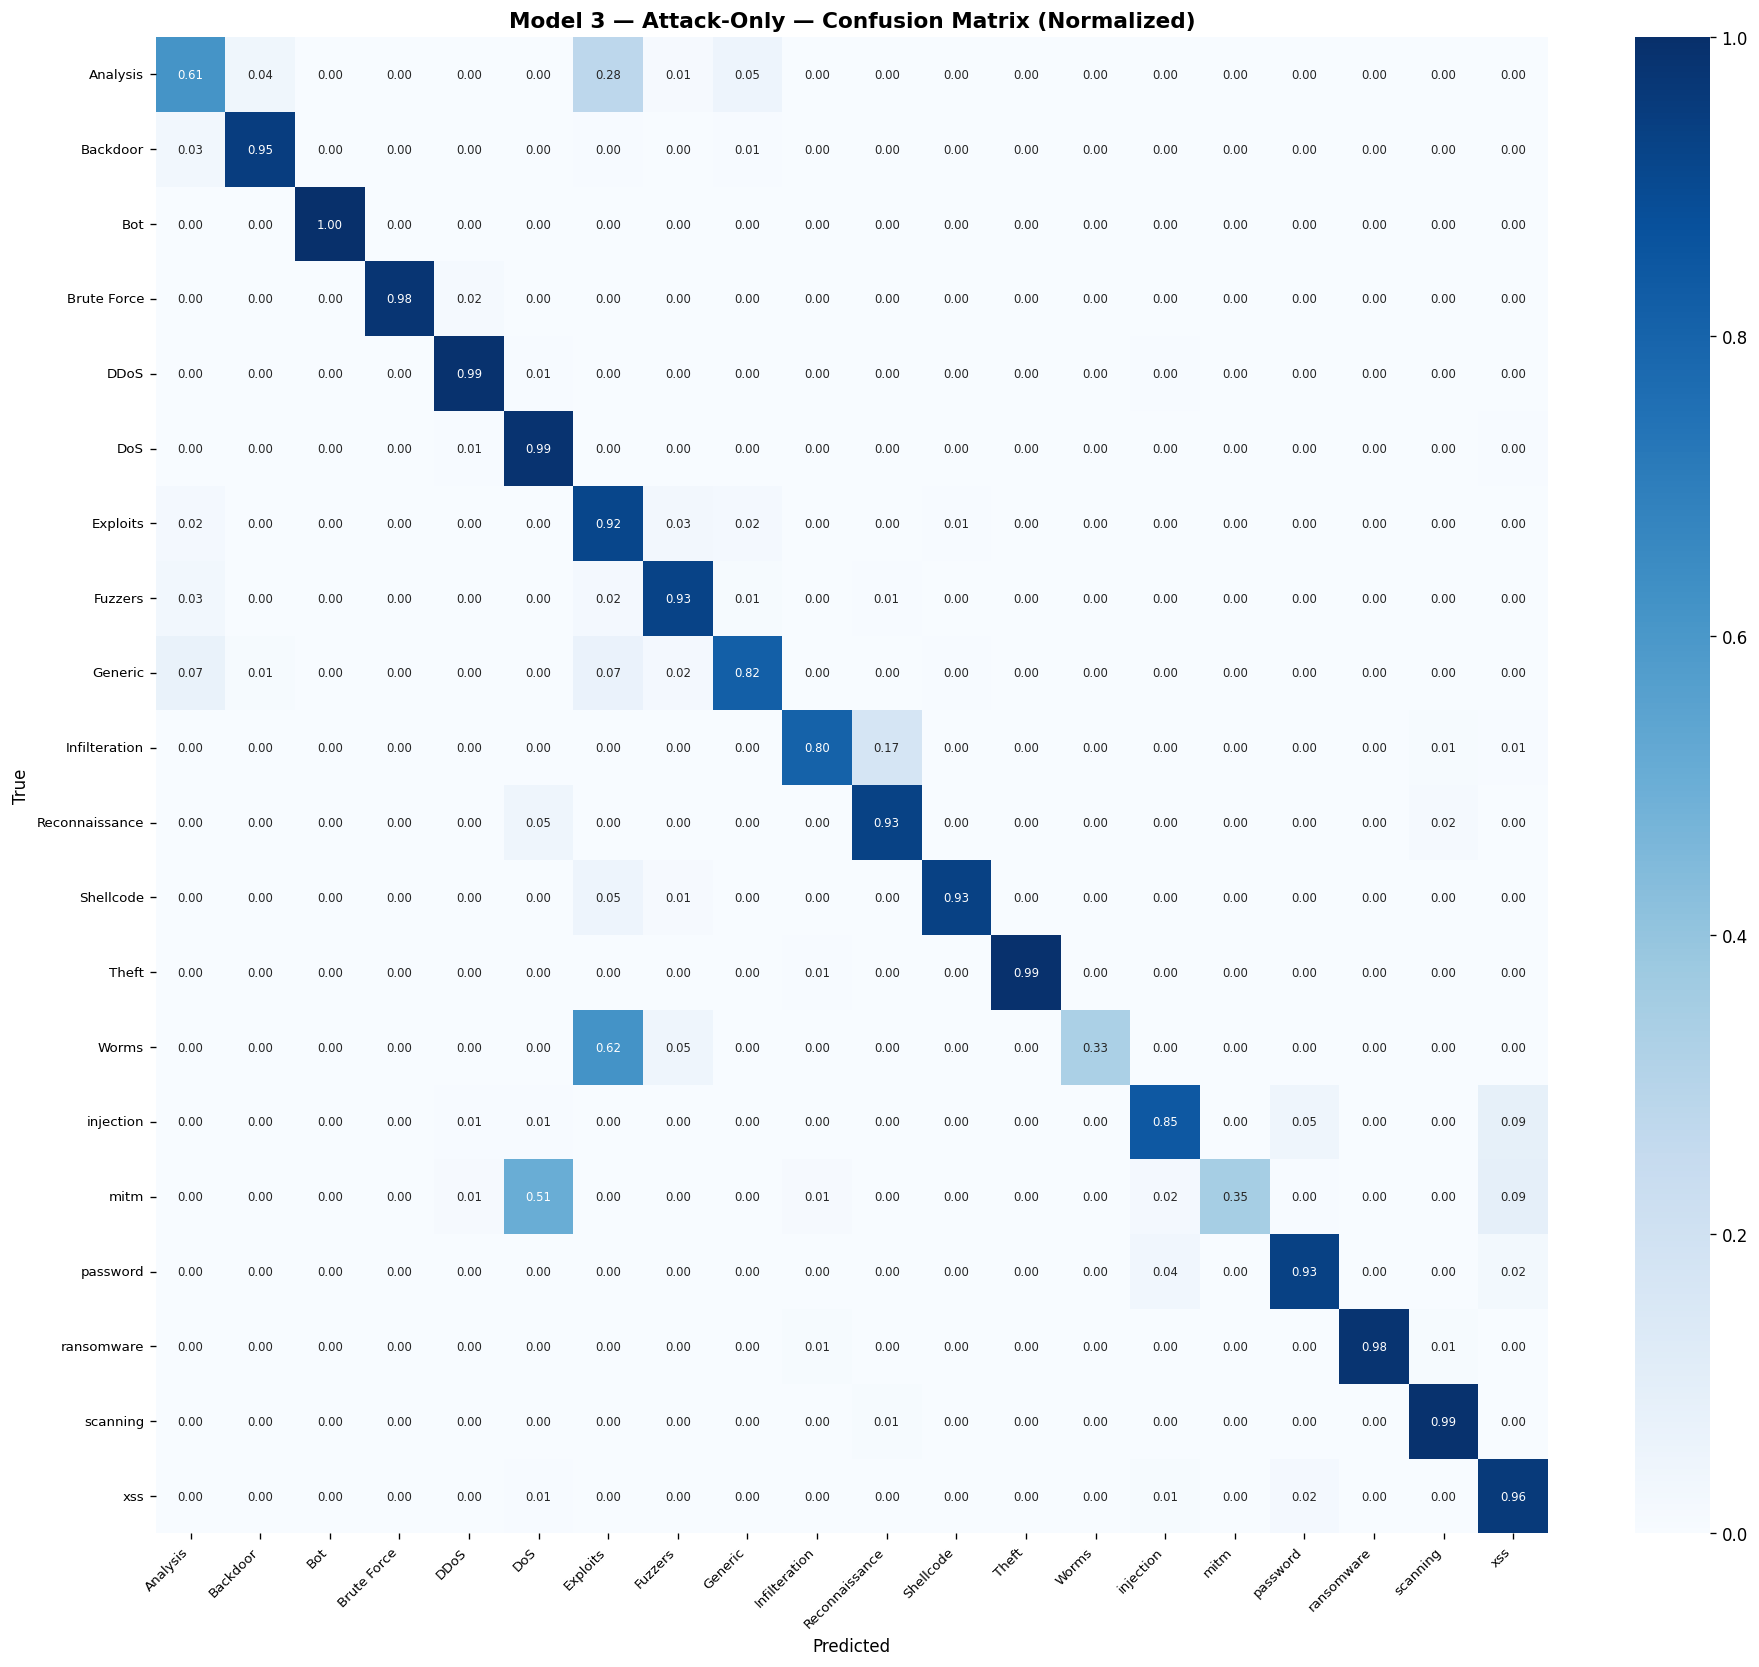

In [87]:
cm = confusion_matrix(y_test_att_remap, preds_att, normalize='true')
fig, ax = plt.subplots(figsize=(16, 14), dpi=120)
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=attack_classes,
            yticklabels=attack_classes, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Model 3 — Attack-Only — Confusion Matrix (Normalized)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('True')
ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class F1 bar chart

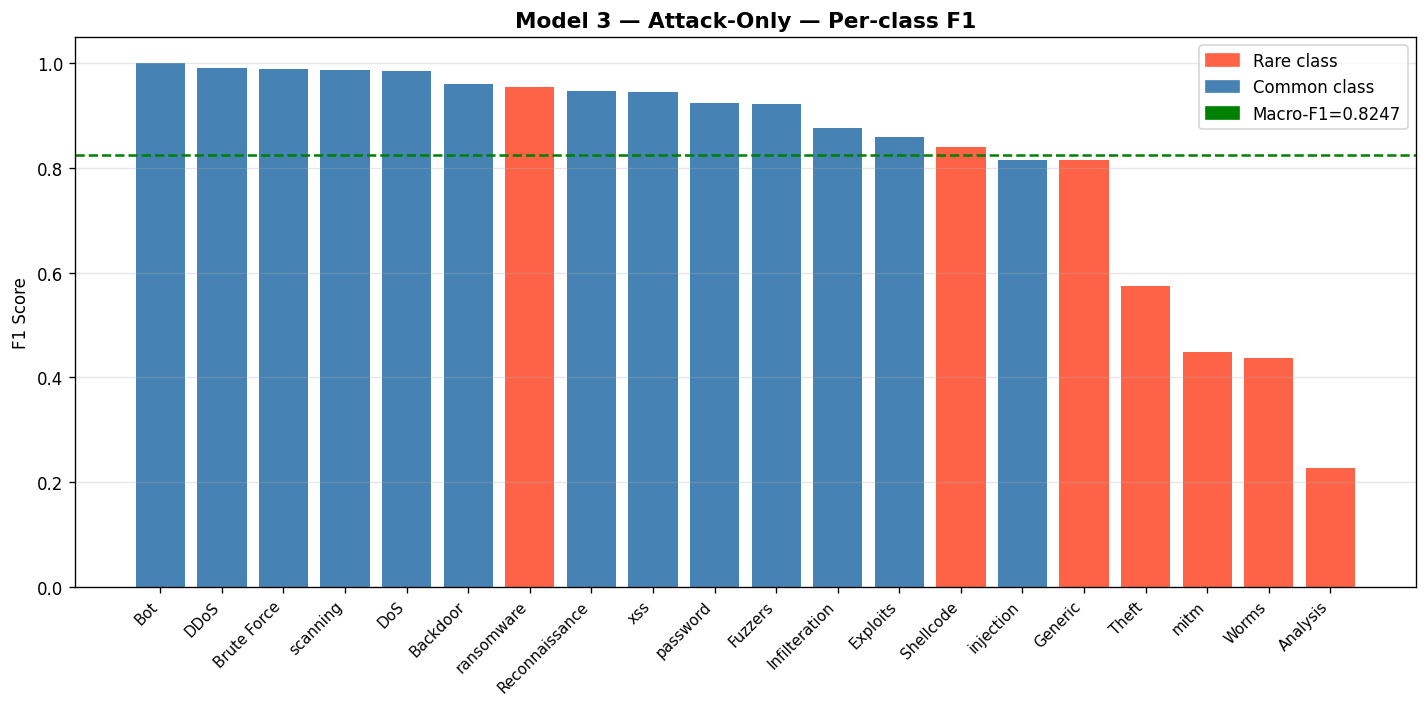

In [88]:
report_att = classification_report(y_test_att_remap, preds_att,
                                    target_names=attack_classes,
                                    output_dict=True, zero_division=0)
f1_vals_att  = {cls: report_att[cls]['f1-score'] for cls in attack_classes}
f1_df_att    = pd.DataFrame(list(f1_vals_att.items()), columns=['class', 'f1'])
f1_df_att    = f1_df_att.sort_values('f1', ascending=False)
macro_f1_att = report_att['macro avg']['f1-score']

rare   = {'Worms','Shellcode','Analysis','Theft','ransomware','mitm','Generic'}
colors = ['tomato' if c in rare else 'steelblue' for c in f1_df_att['class']]

fig, ax = plt.subplots(figsize=(12, 6), dpi=120)
ax.bar(f1_df_att['class'], f1_df_att['f1'], color=colors)
ax.axhline(macro_f1_att, color='green', linestyle='--',
           label=f'Macro-F1 = {macro_f1_att:.4f}')
ax.set_title('Model 3 — Attack-Only — Per-class F1',
             fontsize=13, fontweight='bold')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1.05)
plt.xticks(rotation=45, ha='right', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
patches = [mpatches.Patch(color='tomato',    label='Rare class'),
           mpatches.Patch(color='steelblue', label='Common class'),
           mpatches.Patch(color='green',     label=f'Macro-F1={macro_f1_att:.4f}')]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

## Per_class Precision_Recall heatmap

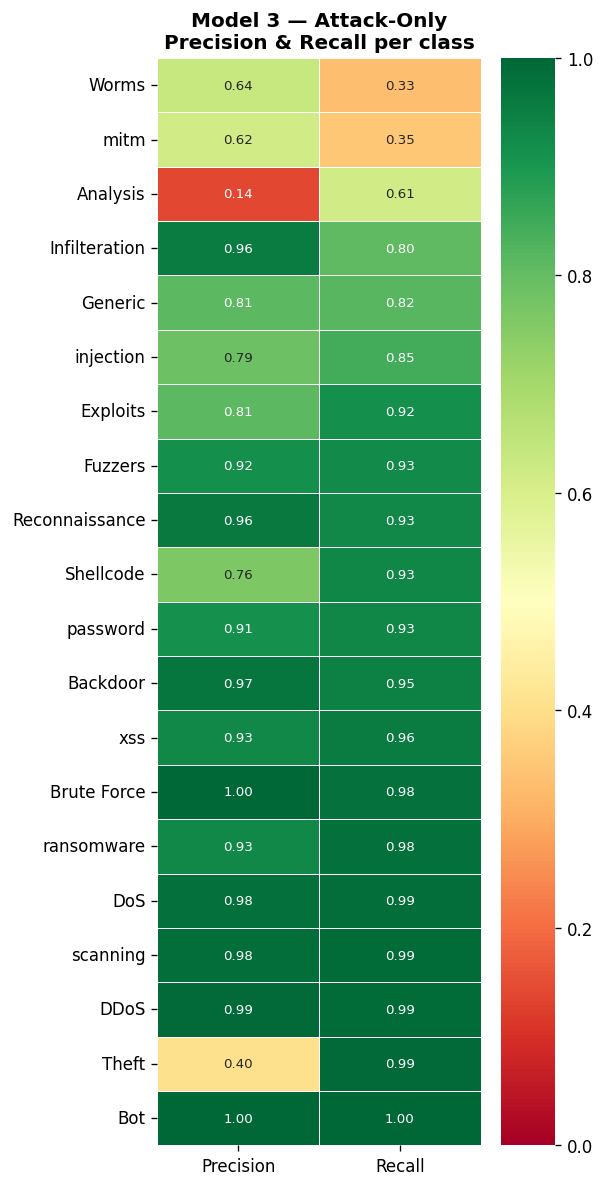

In [89]:
prec_vals_att = {cls: report_att[cls]['precision'] for cls in attack_classes}
rec_vals_att  = {cls: report_att[cls]['recall']    for cls in attack_classes}
pr_df_att     = pd.DataFrame({'Precision': prec_vals_att, 'Recall': rec_vals_att})
pr_df_att     = pr_df_att.sort_values('Recall', ascending=True)

fig, ax = plt.subplots(figsize=(5, 10), dpi=120)
sns.heatmap(pr_df_att, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size': 8})
ax.set_title('Model 3 — Attack-Only\nPrecision & Recall per class',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_precision_recall_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

## Feature Importance (Gradient-based, Top 20)

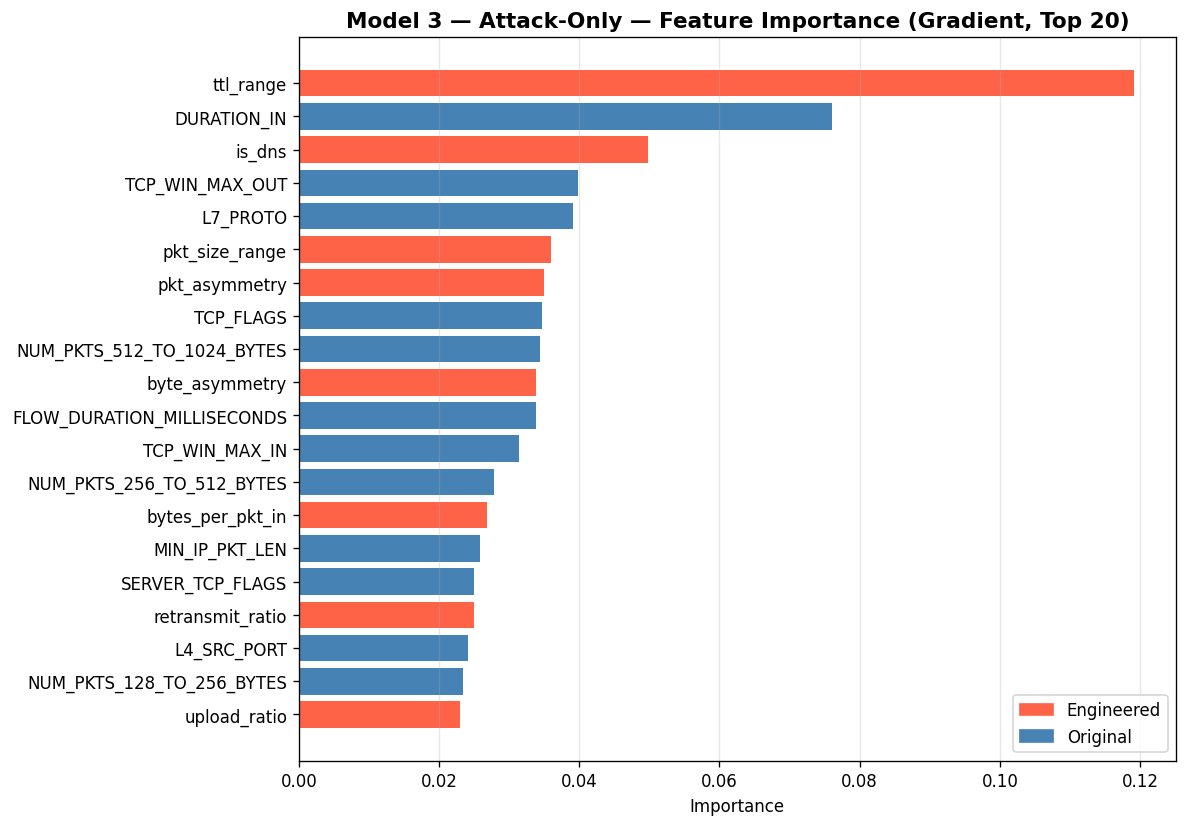

In [90]:
importance = res_att.feature_importances_
feat_df    = pd.DataFrame({'feature': mi_cols, 'importance': importance})
feat_df    = feat_df.sort_values('importance', ascending=False).head(20)
colors     = ['tomato' if f in engineered else 'steelblue'
               for f in feat_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(feat_df['feature'][::-1], feat_df['importance'][::-1], color=colors[::-1])
ax.set_title('Model 3 — Attack-Only — Feature Importance (Gradient, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/m3_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()


In [91]:
np.save(f'{models_dir}/preds_att.npy', preds_att)
del preds_att

del res_att
del X_val_att
del y_train_att_multi, y_val_att_multi, y_val_att_remap
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


55591

In [92]:
preds_bin   = np.load(f'{models_dir}/preds_bin.npy')
preds_multi = np.load(f'{models_dir}/preds_multi.npy')
preds_att   = np.load(f'{models_dir}/preds_att.npy')


## Residual MLP — Gradient Feature Importance Visualization
per-sample gradient magnitudes replace CLS attention — same visual interface

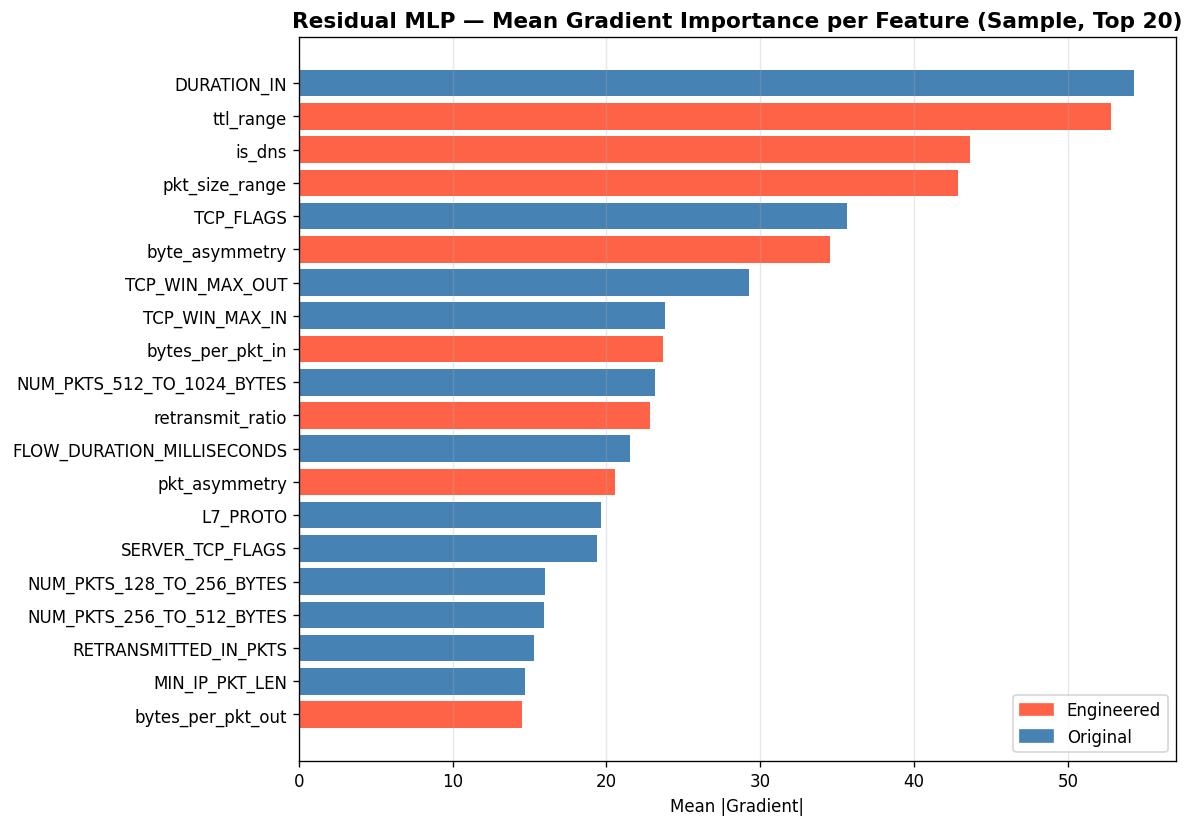

5587

In [93]:
res_multi_reload = ResidualMLPClassifier(**RESMLP_PARAMS)
res_multi_reload._dev = device
res_multi_reload.load_model(f'{models_dir}/resmlp_multiclass.pt')

# Use attack-only test set for the visual (matches original notebook intent)
idx_s    = np.random.choice(len(X_test_att), size=2000, replace=False)
X_sample = X_test_att[idx_s]
y_sample = y_test_att_remap[idx_s]
explain_matrix, _ = res_multi_reload.explain(X_sample)
mean_attention     = explain_matrix.mean(axis=0)

attn_df = pd.DataFrame({'feature': mi_cols, 'attention': mean_attention})
attn_df = attn_df.sort_values('attention', ascending=False).head(20)
colors  = ['tomato' if f in engineered else 'steelblue' for f in attn_df['feature']]

fig, ax = plt.subplots(figsize=(10, 7), dpi=120)
ax.barh(attn_df['feature'][::-1], attn_df['attention'][::-1], color=colors[::-1])
ax.set_title('Residual MLP — Mean Gradient Importance per Feature (Sample, Top 20)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |Gradient|')
patches = [mpatches.Patch(color='tomato',    label='Engineered'),
           mpatches.Patch(color='steelblue', label='Original')]
ax.legend(handles=patches)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(f'{plots_dir}/resmlp_attention_mean.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')
gc.collect()


##  Per-class gradient importance heatmap — shows Residual MLP uses different features per attack type

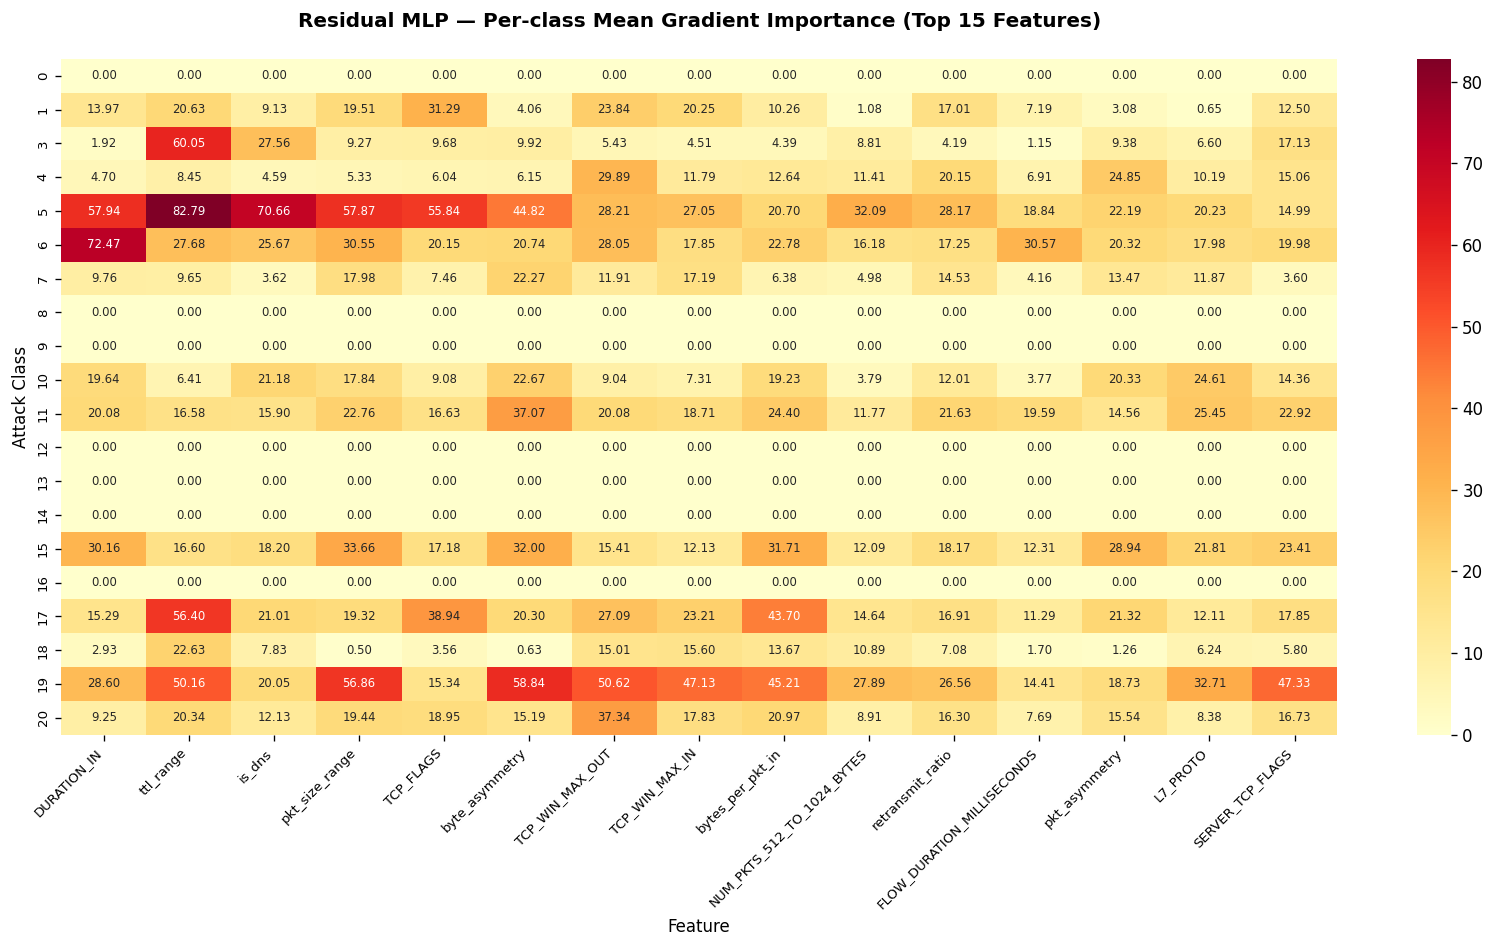

5477

In [94]:
top15_idx   = np.argsort(mean_attention)[::-1][:15]
top15_feats = [mi_cols[i] for i in top15_idx]

att_class_names = le_att.classes_
n_att_classes   = len(att_class_names)
class_attn      = np.zeros((n_att_classes, 15))

for cls_idx in range(n_att_classes):
    mask = y_sample == cls_idx
    if mask.sum() > 0:
        class_attn[cls_idx] = explain_matrix[mask][:, top15_idx].mean(axis=0)

fig, ax = plt.subplots(figsize=(14, 8), dpi=120)
sns.heatmap(class_attn,
            xticklabels=top15_feats,
            yticklabels=att_class_names,
            cmap='YlOrRd', ax=ax,
            annot=True, fmt='.2f',
            annot_kws={'size': 7})
ax.set_title('Residual MLP — Per-class Mean Gradient Importance (Top 15 Features)\n',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Attack Class')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(f'{plots_dir}/resmlp_attention_per_class.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close('all')
gc.collect()


In [95]:
del res_multi_reload, explain_matrix, X_sample, y_sample, mean_attention
del preds_bin, preds_multi, preds_att
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()


0

## Comparison between different papers done in the same dataset

In [96]:
papers = [
    "Sarhan\n2022",
    "Wijethilaka\n2025",
    "Mouatassim\n2024",
    "Bouzaachane\n2025",
    "Gu\n2024",
    "Krupski\n2024",
    "Komisarek\n2021",
    "Gouda\n2024",
    "Adeniyi\n2024",
    "ResMLP\n MyModels"
]


In [101]:
# Binary
binary_scores = [
    0.9800,      # Sarhan ET Binary
    0.9480,      # Wijethilaka RF
    0.999939,    # Mouatassim XGB Binary
    1.0000,      # Bouzaachane RF Binary
    np.nan,      # Gu
    0.9530,      # Krupski DT 8feat
    0.9800,      # Komisarek RF
    0.9910,      # Gouda RF
    0.9890,      # Adeniyi AE-MLP
    0.9811       
]
# Full multiclass
multi_scores = [
    0.9700,      # Sarhan ET Multi
    0.8750,      # Wijethilaka LSTM
    0.9928,      # Mouatassim XGB Multi
    0.9900,      # Bouzaachane DBN Multi
    0.8900,      # Gu GNN
    0.9720,      # Krupski DT 30feat
    np.nan,
    np.nan,
    np.nan,
    0.9700     
]
# Attack-only multiclass
attack_only_scores = [
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    np.nan,
    0.98     
]


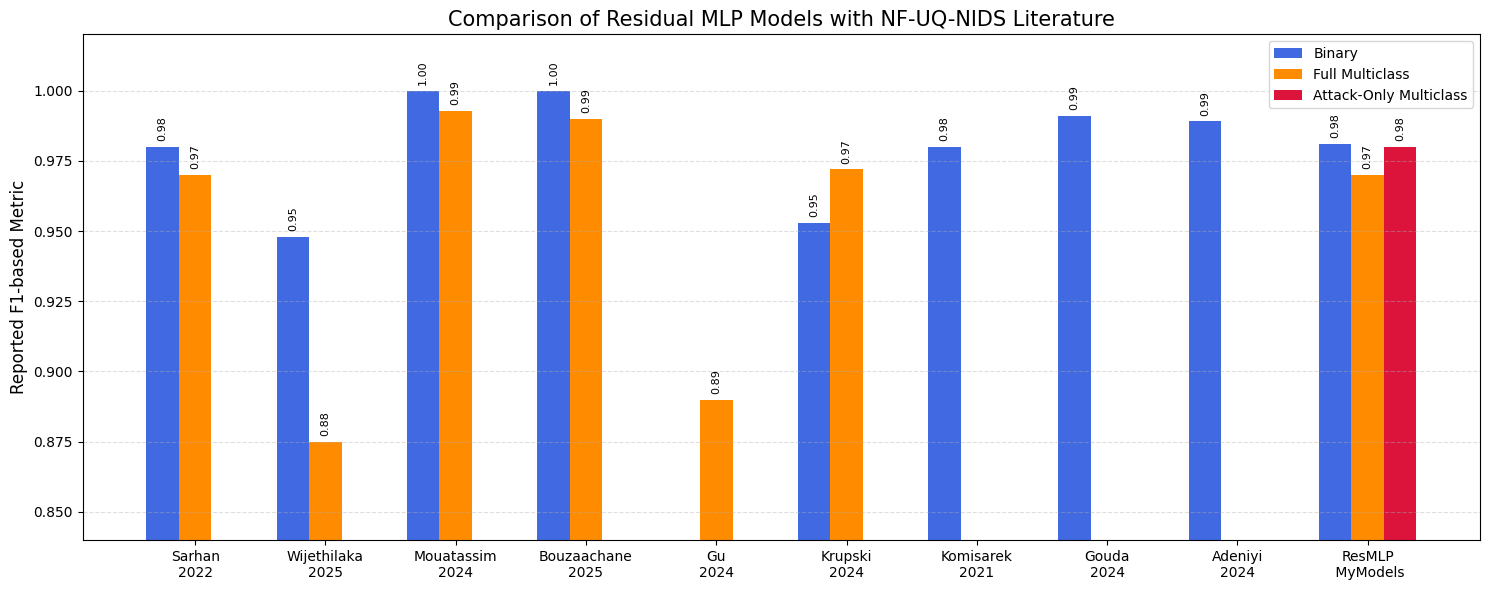

In [102]:
x = np.arange(len(papers))
width = 0.25
plt.figure(figsize=(15, 6))
bars1 = plt.bar(x - width,binary_scores,width,label='Binary',color='royalblue')
bars2 = plt.bar(x,multi_scores, width,label='Full Multiclass',color='darkorange')
bars3 = plt.bar(x + width,attack_only_scores,width,label='Attack-Only Multiclass',color='crimson')



for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()

        if not np.isnan(height):
            plt.text(bar.get_x() + bar.get_width()/2,height + 0.002,f"{height:.2f}", ha='center',va='bottom',fontsize=8, rotation=90 )


plt.xticks(x, papers, fontsize=10)
plt.ylabel("Reported F1-based Metric", fontsize=12)
plt.title("Comparison of Residual MLP Models with NF-UQ-NIDS Literature",fontsize=15)

plt.ylim(0.84, 1.02)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.legend()
plt.tight_layout()
plt.savefig(f'{plots_dir}/papers_Comparison.png', dpi=120, bbox_inches='tight')         
plt.show()

## Save models and artefacts

In [99]:
import os
import shutil
from IPython.display import display, FileLink

plots_dir = '/kaggle/working/plots_ftt'
plots_zip = 'ftt_plots.zip'

if os.path.exists(plots_dir):
 
    shutil.make_archive('ftt_plots', 'zip', plots_dir)
    print(" FTT Plots:")
    display(FileLink(plots_zip))
else:
    print(f" Directory not found: {plots_dir}")


 FTT Plots:


/kaggle/working/ftt_plots.zip

In [100]:
models_dir = '/kaggle/working/models_ftt'
models_zip = 'ftt_models.zip'

if os.path.exists(models_dir):
    
    shutil.make_archive('ftt_models', 'zip', models_dir)
    print(" FTT Models:")
    display(FileLink(models_zip))
else:
    print(f" Directory not found: {models_dir}")


 FTT Models:


/kaggle/working/ftt_models.zip